<a href="https://colab.research.google.com/github/nashinho/ML2/blob/main/Tarea3ML2UAI202610.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UAI Machine Learning 2

## Tarea 3


**Dataset:** Rice Cammeo and Osmancik  
**Objetivo:** construir, optimizar, evaluar e interpretar un modelo que clasifique granos de arroz turco como `Cammeo` u `Osmancik` a partir de siete medidas geométricas extraídas de imágenes.

### Estudiantes:


*   Fernando Barrera
*   José Ignacio Burgos
*   Felipe Calderón
*   Sebastian Caamaño

# Desarrollo


## 0. Preparación y carga de datos

Cada fila representa **un grano de arroz**. Las siete variables predictoras describen su tamaño y forma; `Class` es la respuesta y debe permanecer fuera de los predictores. El archivo ARFF almacena sus etiquetas como bytes, por lo que se decodifican explícitamente.

Se fija una semilla para que la partición, la validación y los modelos sean reproducibles. No se instala ninguna librería dentro del notebook: se utilizan las dependencias ya disponibles en el entorno del proyecto.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.io import arff

warnings.filterwarnings("ignore", category=FutureWarning)
RANDOM_STATE = 2026
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)

rutas = [
    Path("Rice_Cammeo_Osmancik.arff"),
    Path("../Rice_Cammeo_Osmancik.arff"),

]
ruta_arff = next((ruta for ruta in rutas if ruta.exists()), None)
if ruta_arff is None:
    raise FileNotFoundError("No se encontró Rice_Cammeo_Osmancik.arff en las rutas esperadas.")

datos_arff, metadatos_arff = arff.loadarff(ruta_arff)
df = pd.DataFrame(datos_arff)
for columna in df.select_dtypes(include="object"):
    df[columna] = df[columna].str.decode("utf-8")

print(f"Archivo: {ruta_arff.resolve()}")
print(f"Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
display(df.head())

Archivo: /Users/fernandobarreragutierrez/projects/ML2-nashinho/Rice_Cammeo_Osmancik.arff
Dimensiones: 3,810 filas x 8 columnas


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231.0,525.578979,229.749878,85.093788,0.928882,15617.0,0.572896,Cammeo
1,14656.0,494.311005,206.020065,91.730972,0.895405,15072.0,0.615436,Cammeo
2,14634.0,501.122009,214.106781,87.768288,0.912118,14954.0,0.693259,Cammeo
3,13176.0,458.342987,193.337387,87.448395,0.891861,13368.0,0.640669,Cammeo
4,14688.0,507.166992,211.743378,89.312454,0.906691,15262.0,0.646024,Cammeo


## 1. Exploración: qué datos existen, cuáles aportan, nulos, duplicados
Realice una exploración de datos para ver qué datos existen, cuales de ellos entregan
información relevante para el problema y cuales no, eliminación (si corresponde) de
datos nulos y duplicados, entre otros.





En esta primera etapa se realiza un análisis exploratorio del conjunto de datos. El objetivo es comprender su estructura, revisar la calidad de los datos y evaluar qué variables aportan información para diferenciar las clases **Cammeo** y **Osmancik**.

En particular, se analizan:

- Dimensiones, estructura general y estadísticas descriptivas.
- Tipo de las variables y decodificación de la variable objetivo `Class`.
- Balance de la variable objetivo.
- Valores nulos (explícitos y disfrazados) y registros duplicados.
- Validez física de las medidas y valores atípicos (outliers).
- Correlación y redundancia entre variables, sin usar `Class`.
- Relevancia de cada variable para distinguir ambas clases, usando solo el conjunto de entrenamiento.

Las decisiones sobre **filas** (nulos, duplicados, atípicos) y sobre **redundancia entre variables** se toman en este punto. La selección definitiva de las variables que entran al modelo se hace en el Punto 2, junto con la elección del modelo.

### 1.1 Comprensión general del dataset

El dataset proviene de Cinar y Koklu (2019), *Classification of Rice Varieties Using Artificial Intelligence Methods*. Contiene mediciones geométricas obtenidas a partir de imágenes de granos de arroz de dos variedades turcas: **Cammeo** y **Osmancik**. La **unidad de análisis** es un grano de arroz: cada fila corresponde a un grano distinto.

Las variables disponibles son:

- **Area:** número de píxeles contenidos dentro del grano.
- **Perimeter:** longitud del contorno del grano, medida como la distancia recorrida por los píxeles del borde.
- **Major_Axis_Length:** longitud del eje mayor de la elipse que representa al grano.
- **Minor_Axis_Length:** longitud del eje menor de esa elipse.
- **Eccentricity:** qué tan alargada es la elipse (0 = círculo; cercano a 1 = muy alargada).
- **Convex_Area:** número de píxeles de la envoltura convexa mínima del grano.
- **Extent:** relación entre el área del grano y el área de su bounding box en la imagen.
- **Class:** variedad del arroz (Cammeo u Osmancik). Es la variable objetivo.

Las primeras observaciones ya se mostraron en la Sección 0. Aquí se revisan las dimensiones y las estadísticas descriptivas.

In [2]:
print("Dimensiones del dataset:", df.shape)
print("\nEstadísticas descriptivas de los predictores:")
display(df.describe().T)

Dimensiones del dataset: (3810, 8)

Estadísticas descriptivas de los predictores:


,count,mean,std,min,25%,50%,75%,max
Area,3810.0,12667.727559,1732.367706,7551.000000,11370.500000,12421.500000,13950.000000,18913.000000
Perimeter,3810.0,454.239180,35.597081,359.100006,426.144753,448.852493,483.683746,548.445984
Major_Axis_Length,3810.0,188.776222,17.448679,145.264465,174.353855,185.810059,203.550438,239.010498
Minor_Axis_Length,3810.0,86.313750,5.729817,59.532406,82.731695,86.434647,90.143677,107.542450
Eccentricity,3810.0,0.886871,0.020818,0.777233,0.872402,0.889050,0.902588,0.948007
Convex_Area,3810.0,12952.496850,1776.972042,7723.000000,11626.250000,12706.500000,14284.000000,19099.000000
Extent,3810.0,0.661934,0.077239,0.497413,0.598862,0.645361,0.726562,0.861050


#### Interpretación

El conjunto de datos contiene **3.810 observaciones y 8 variables**. Siete son características numéricas que describen propiedades geométricas de los granos, y una es la variable objetivo `Class`. El problema es, por lo tanto, una tarea de **clasificación supervisada binaria**: distinguir Cammeo de Osmancik a partir de las características observadas.

No hay identificadores, textos libres ni otras columnas que deban descartarse a priori por su naturaleza.

Las siete medidas describen al grano desde dos ángulos:

- **Tamaño**, en píxeles: `Area`, `Perimeter`, `Major_Axis_Length`, `Minor_Axis_Length` y `Convex_Area`.
- **Forma**, sin unidades: `Eccentricity` y `Extent`.

Esta distinción es clave para el análisis de redundancia de la Sección 1.6.

Las estadísticas descriptivas muestran que las **escalas son muy distintas**. `Area` y `Convex_Area` están en el orden de 10⁴, los ejes y el perímetro en 10², y `Eccentricity` y `Extent` entre 0 y 1. Esto no afecta a los modelos basados en árboles, pero sí obliga a estandarizar si en el Punto 2 se usa un modelo basado en distancias o lineal. En ese caso, la estandarización debe ajustarse solo con los datos de entrenamiento.

### 1.2 Auditoría de tipos y decodificación del target

Se contrasta el tipo declarado en el encabezado del ARFF con el tipo que asigna pandas, y se revisa la cardinalidad (número de valores distintos) de cada variable. El objetivo es detectar variables mal tipadas: códigos que parecen números, números leídos como texto, o variables constantes que no pueden aportar información.

Además, se verifica explícitamente la **decodificación del target**. `scipy.io.arff.loadarff` lee las variables nominales como **bytes** (`b'Cammeo'`), no como texto. Se ven casi igual en un `.head()`, pero `b'Cammeo' == 'Cammeo'` es `False`: sin decodificar, cualquier filtro o conteo por clase fallaría en silencio. En la Sección 0 se aplicó `.str.decode("utf-8")`; aquí se comprueba que funcionó.

In [3]:
predictores = [c for c in df.columns if c != "Class"]
tipo_arff = dict(zip(metadatos_arff.names(), metadatos_arff.types()))

auditoria = pd.DataFrame({
    "tipo_ARFF": pd.Series(tipo_arff),
    "dtype_pandas": df.dtypes.astype(str),
    "valores_distintos": df.nunique(),
    "pct_distintos": (df.nunique() / len(df) * 100).round(1),
})
auditoria["solo_enteros"] = [bool((df[c] % 1 == 0).all()) if c in predictores else np.nan for c in auditoria.index]
display(auditoria)

print("Tipos declarados en el encabezado del ARFF:")
with open(ruta_arff, "rt") as archivo:
    print("".join(linea for linea in archivo if linea.startswith("@ATTRIBUTE")))

,tipo_ARFF,dtype_pandas,valores_distintos,pct_distintos,solo_enteros
Area,numeric,float64,2828,74.2,True
Perimeter,numeric,float64,3738,98.1,False
Major_Axis_Length,numeric,float64,3808,99.9,False
Minor_Axis_Length,numeric,float64,3804,99.8,False
Eccentricity,numeric,float64,3803,99.8,False
Convex_Area,numeric,float64,2857,75.0,True
Extent,numeric,float64,3804,99.8,False
Class,nominal,object,2,0.1,NaN


Tipos declarados en el encabezado del ARFF:
@ATTRIBUTE Area Integer
@ATTRIBUTE Perimeter Real
@ATTRIBUTE Major_Axis_Length Real
@ATTRIBUTE Minor_Axis_Length Real
@ATTRIBUTE Eccentricity	Real
@ATTRIBUTE Convex_Area	Integer
@ATTRIBUTE Extent Real
@ATTRIBUTE Class {Cammeo, Osmancik}



In [4]:
class_crudo = [valor for valor in datos_arff["Class"]]

display(pd.DataFrame({
    "": ["Tal como lo entrega loadarff", "Después de decodificar (df)"],
    "primer_valor": [repr(class_crudo[0]), repr(df["Class"].iloc[0])],
    "tipo_python": [type(class_crudo[0]).__name__, type(df["Class"].iloc[0]).__name__],
    "filas_iguales_a_'Cammeo'": [sum(valor == "Cammeo" for valor in class_crudo), int((df["Class"] == "Cammeo").sum())],
}).set_index(""))
print("Niveles de Class después de decodificar:", sorted(df["Class"].unique()))
print("Niveles declarados en el ARFF:         ", sorted(metadatos_arff["Class"][1]))

,primer_valor,tipo_python,filas_iguales_a_'Cammeo'
,,,
Tal como lo entrega loadarff,np.bytes_(b'Cammeo'),bytes_,0
Después de decodificar (df),'Cammeo',str,1630


Niveles de Class después de decodificar: ['Cammeo', 'Osmancik']
Niveles declarados en el ARFF:          ['Cammeo', 'Osmancik']


#### Interpretación

- **`Class` está correctamente decodificada.** Tal como la entrega `loadarff`, es de tipo `bytes` y ninguna fila coincide con el texto `'Cammeo'`. Después de decodificar es `str`, 1.630 filas coinciden, y los niveles son exactamente los dos declarados en el ARFF (`Cammeo`, `Osmancik`), sin categorías extra ni espacios.
- **`Area` y `Convex_Area`** se declaran `Integer` en el ARFF (son conteos de píxeles) y se confirma que solo contienen enteros. `loadarff` las lee como `float64`, lo que no altera su valor numérico, así que no se convierten.
- **Las otras cinco variables** son reales continuas, con casi tantos valores distintos como filas.
- **No hay categóricas disfrazadas de número:** todos los predictores son magnitudes físicas y el orden de sus valores tiene significado.
- **No hay variables constantes.** La de menor cardinalidad, `Area`, tiene 2.828 valores distintos (74%).

**Decisión:** los siete predictores se mantienen como numéricos y no requieren codificación. Para modelar, `Class` se transformará a binaria en la Sección 1.7, con `Cammeo` = 1.

### 1.3 Balance de la variable objetivo

Antes de modelar es importante conocer la distribución de `Class`, por dos razones. Un desbalance importante podría afectar el entrenamiento. Además, el balance define la **línea base** contra la que se comparan las métricas: un clasificador que siempre predice la clase mayoritaria.

,Cantidad,Porcentaje (%)
Class,,
Osmancik,2180,57.22
Cammeo,1630,42.78


Accuracy de un modelo que siempre predice 'Osmancik': 57.22%
Razón de desbalance (mayoritaria / minoritaria): 1.34


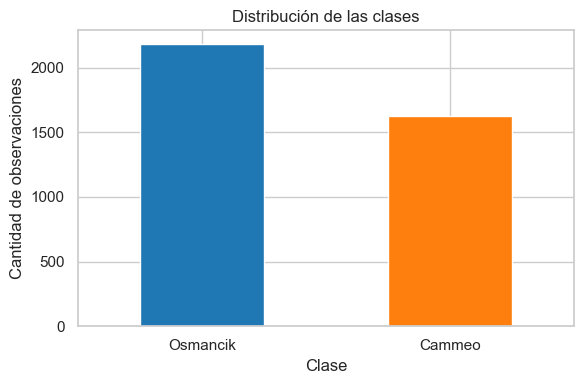

In [5]:
balance_clases = pd.DataFrame({
    "Cantidad": df["Class"].value_counts(),
    "Porcentaje (%)": (df["Class"].value_counts(normalize=True) * 100).round(2),
})
display(balance_clases)

clase_mayoritaria = balance_clases["Cantidad"].idxmax()
print(f"Accuracy de un modelo que siempre predice '{clase_mayoritaria}': "
      f"{balance_clases.loc[clase_mayoritaria, 'Porcentaje (%)']:.2f}%")
print(f"Razón de desbalance (mayoritaria / minoritaria): "
      f"{balance_clases['Cantidad'].max() / balance_clases['Cantidad'].min():.2f}")

fig, ax = plt.subplots(figsize=(6, 4))
balance_clases["Cantidad"].plot.bar(ax=ax, color=["tab:blue", "tab:orange"], rot=0)
ax.set_title("Distribución de las clases")
ax.set_xlabel("Clase")
ax.set_ylabel("Cantidad de observaciones")
plt.tight_layout()
plt.show()

#### Interpretación del balance de clases

La distribución de la variable objetivo es:

- **Osmancik:** 2.180 observaciones (57,22%).
- **Cammeo:** 1.630 observaciones (42,78%).

La razón entre clases es 1,34. Hay una diferencia, pero **no un desbalance severo**: ambas categorías tienen una cantidad considerable de observaciones. De aquí salen tres decisiones para los puntos siguientes:

1. **No se aplican técnicas de rebalanceo** (sobremuestreo, submuestreo o pesos de clase). Con 1.630 ejemplos de la clase minoritaria, el modelo tiene suficiente información de ambas.
2. **La línea base es 57,22% de accuracy**, lo que obtiene un modelo que siempre predice Osmancik. Toda métrica de accuracy debe leerse contra ese valor, no contra 0% ni contra 50%. Como el accuracy puede ocultar un mal desempeño en una clase, también se reportarán métricas por clase (precision, recall, F1) y la matriz de confusión.
3. **La partición entrenamiento/prueba y la validación cruzada se estratifican por `Class`**, para que ambos subconjuntos conserven la proporción 57/43.

### 1.4 Valores nulos y registros duplicados

#### Valores nulos

Se verifica la existencia de valores faltantes en cada variable, porque varios algoritmos no pueden trabajar con datos nulos. Además de los nulos explícitos (`NaN`, que es como `loadarff` representa el símbolo `?` del ARFF), se buscan **faltantes disfrazados**: infinitos, o ceros y negativos en medidas que físicamente deben ser positivas (ningún grano real tiene área, perímetro o ejes iguales a cero).

In [6]:
nulos = pd.DataFrame({
    "Nulos": df.isnull().sum(),
    "Porcentaje (%)": (df.isnull().mean() * 100).round(2),
    "Infinitos": [int(np.isinf(df[c]).sum()) if c in predictores else 0 for c in df.columns],
    "Ceros o negativos": [int((df[c] <= 0).sum()) if c in predictores else 0 for c in df.columns],
})
display(nulos)
print("Total de valores nulos:", int(df.isnull().sum().sum()))
print("Total de faltantes disfrazados:", int(nulos[["Infinitos", "Ceros o negativos"]].to_numpy().sum()))

,Nulos,Porcentaje (%),Infinitos,Ceros o negativos
Area,0,0.0,0,0
Perimeter,0,0.0,0,0
Major_Axis_Length,0,0.0,0,0
Minor_Axis_Length,0,0.0,0,0
Eccentricity,0,0.0,0,0
Convex_Area,0,0.0,0,0
Extent,0,0.0,0,0
Class,0,0.0,0,0


Total de valores nulos: 0
Total de faltantes disfrazados: 0


No se detectaron valores nulos en ninguna variable, ni tampoco faltantes disfrazados: cero infinitos y ningún cero o negativo en medidas que deben ser positivas.

**Decisión:** no se eliminan observaciones ni se aplican técnicas de imputación. El criterio es explícito: solo se trata un faltante que existe. Se conservan las 3.810 observaciones.

#### Registros duplicados

Los registros duplicados pueden introducir información repetida y sesgar el entrenamiento. Si un mismo grano quedara a la vez en entrenamiento y en prueba, además, inflaría las métricas. Se revisan tres casos, porque cada uno significa algo distinto:

1. **Filas idénticas en todas las columnas:** un grano registrado dos veces.
2. **Filas idénticas en los siete predictores**, sin mirar `Class`: dos granos con las mismas medidas.
3. **Duplicados contradictorios:** mismos predictores con distinta `Class`. Serían ruido de etiqueta que ningún modelo podría resolver.

In [7]:
duplicados = int(df.duplicated().sum())
duplicados_predictores = int(df[predictores].duplicated().sum())
contradictorios = int((df.groupby(predictores)["Class"].nunique() > 1).sum())

display(pd.DataFrame({
    "Tipo de duplicado": [
        "Filas idénticas (predictores + Class)",
        "Mismos predictores (sin mirar Class)",
        "Mismos predictores con distinta Class",
    ],
    "Cantidad": [duplicados, duplicados_predictores, contradictorios],
    "Porcentaje (%)": [round(v / len(df) * 100, 2) for v in [duplicados, duplicados_predictores, contradictorios]],
}))

,Tipo de duplicado,Cantidad,Porcentaje (%)
0,Filas idénticas (predictores + Class),0,0.0
1,Mismos predictores (sin mirar Class),0,0.0
2,Mismos predictores con distinta Class,0,0.0


No se encontraron duplicados de ningún tipo: ni filas idénticas, ni granos con las mismas siete medidas, ni casos contradictorios. Es coherente con la naturaleza de los datos, porque cinco de las siete variables son reales continuas y dos granos distintos prácticamente nunca coinciden en todas.

**Decisión:** no corresponde eliminar observaciones por duplicidad, y se mantienen las 3.810 observaciones originales. Si hubiera habido filas idénticas, se habrían eliminado antes de la partición: en este dataset, una coincidencia exacta en siete medidas continuas indicaría la misma imagen procesada dos veces, no dos granos distintos.

### 1.5 Validez de las medidas y valores atípicos

Se revisa la presencia de valores potencialmente atípicos mediante el criterio del rango intercuartílico (IQR). Se considera potencialmente atípico un valor fuera del intervalo

$$[Q_1 - 1{,}5 \times IQR,\ Q_3 + 1{,}5 \times IQR].$$

La detección de un outlier estadístico no significa automáticamente que la observación sea incorrecta. Para distinguir un error de un grano real poco frecuente, se agrega un criterio que el IQR no tiene: la **validez física**. Todas las variables provienen de la geometría de una región en la imagen, así que deben cumplir estas relaciones:

| Regla | Por qué debe cumplirse |
|---|---|
| `Convex_Area` ≥ `Area` | La envoltura convexa contiene al grano. |
| `Major_Axis_Length` ≥ `Minor_Axis_Length` | Por definición de eje mayor y eje menor. |
| 0 ≤ `Eccentricity` < 1 | Rango de la excentricidad de una elipse. |
| 0 < `Extent` ≤ 1 | El grano ocupa una fracción de su bounding box. |

Este análisis no usa `Class`: si un valor es atípico o imposible, lo es sin importar la variedad del grano.

,Regla,Granos que la violan
0,Convex_Area >= Area,0
1,Major_Axis_Length >= Minor_Axis_Length,0
2,0 <= Eccentricity < 1,0
3,0 < Extent <= 1,0


,Outliers,Porcentaje (%),Asimetría
Area,4,0.10,0.33
Perimeter,0,0.00,0.22
Major_Axis_Length,0,0.00,0.26
Minor_Axis_Length,65,1.71,-0.13
Eccentricity,21,0.55,-0.45
Convex_Area,3,0.08,0.32
Extent,0,0.00,0.34


Granos con al menos un valor atípico: 85 (2.23%)


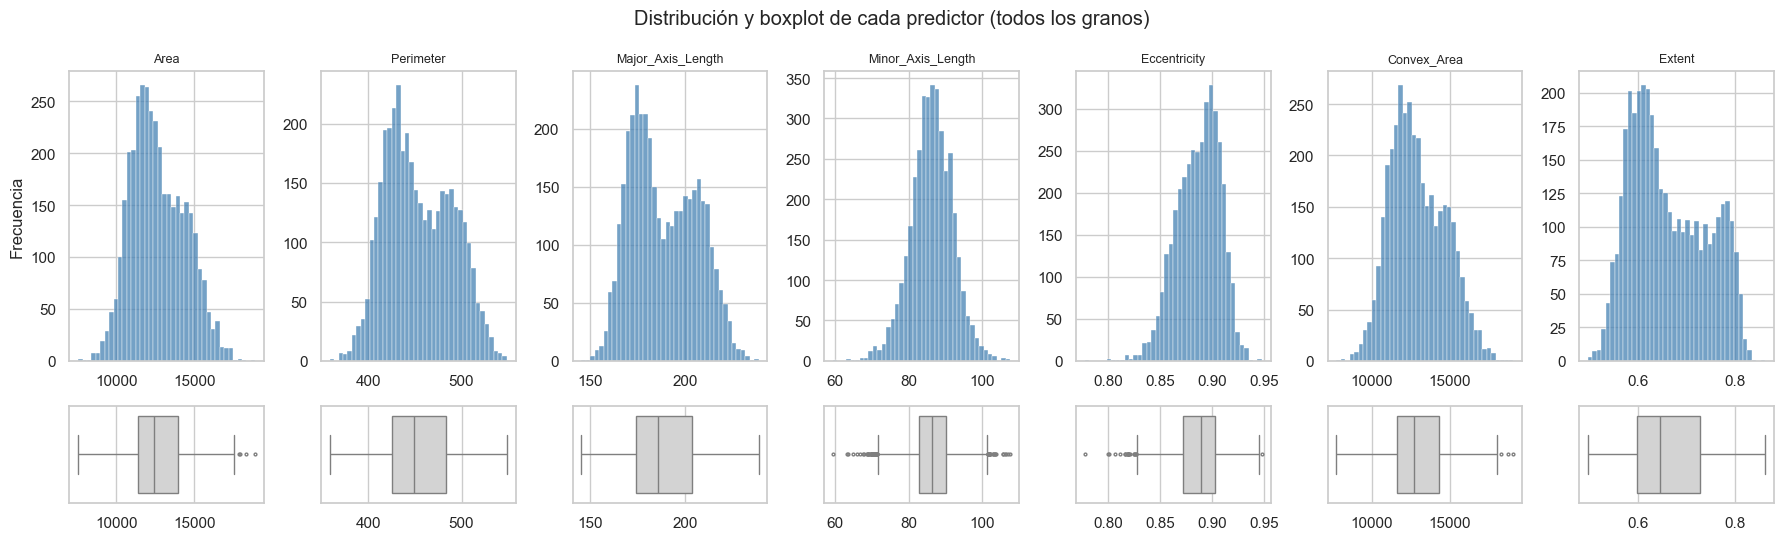

In [8]:
reglas = pd.DataFrame({
    "Regla": ["Convex_Area >= Area", "Major_Axis_Length >= Minor_Axis_Length",
              "0 <= Eccentricity < 1", "0 < Extent <= 1"],
    "Granos que la violan": [
        int((df["Convex_Area"] < df["Area"]).sum()),
        int((df["Major_Axis_Length"] < df["Minor_Axis_Length"]).sum()),
        int(((df["Eccentricity"] < 0) | (df["Eccentricity"] >= 1)).sum()),
        int(((df["Extent"] <= 0) | (df["Extent"] > 1)).sum()),
    ],
})
display(reglas)

Q1 = df[predictores].quantile(0.25)
Q3 = df[predictores].quantile(0.75)
IQR = Q3 - Q1
es_atipico = (df[predictores] < Q1 - 1.5 * IQR) | (df[predictores] > Q3 + 1.5 * IQR)

outliers_df = pd.DataFrame({
    "Outliers": es_atipico.sum(),
    "Porcentaje (%)": (es_atipico.mean() * 100).round(2),
    "Asimetría": df[predictores].skew().round(2),
})
display(outliers_df)
print(f"Granos con al menos un valor atípico: {int(es_atipico.any(axis=1).sum())} "
      f"({es_atipico.any(axis=1).mean() * 100:.2f}%)")

fig, axes = plt.subplots(2, 7, figsize=(18, 5.5), gridspec_kw={"height_ratios": [3, 1]})
for j, variable in enumerate(predictores):
    sns.histplot(df[variable], bins=40, ax=axes[0, j], color="steelblue")
    axes[0, j].set_title(variable, fontsize=9)
    axes[0, j].set_xlabel("")
    axes[0, j].set_ylabel("Frecuencia" if j == 0 else "")
    sns.boxplot(x=df[variable], ax=axes[1, j], color="lightgray", fliersize=2)
    axes[1, j].set_xlabel("")
fig.suptitle("Distribución y boxplot de cada predictor (todos los granos)")
plt.tight_layout()
plt.show()

#### Interpretación de valores atípicos

- **Validez física:** ningún grano viola ninguna de las cuatro reglas. Las medidas son geométricamente coherentes y no hay evidencia de errores de extracción.
- **Atípicos:** 85 granos (2,23%) tienen al menos un valor fuera del intervalo IQR. Se concentran en:
  - `Minor_Axis_Length`: 65 observaciones (1,71%).
  - `Eccentricity`: 21 observaciones (0,55%).
  - `Area` (4) y `Convex_Area` (3) tienen muy pocos; `Perimeter`, `Major_Axis_Length` y `Extent` no tienen ninguno.
- **Forma de las distribuciones:** la asimetría es baja en todas (|asimetría| ≤ 0,45), sin colas largas que obliguen a transformar. Hay dos patrones que anticipan resultados posteriores:
  - `Perimeter` y `Major_Axis_Length` son **bimodales**, como se espera si los datos mezclan dos poblaciones de tamaño distinto. Se verifica en la Sección 1.7.
  - `Extent` también es bimodal, pero por otra razón probable: el bounding box está alineado con los ejes de la imagen, no con el grano, así que `Extent` depende en parte de **cómo quedó rotado el grano** en la foto.

**Decisión: se conservan todos los atípicos.** Cumplen las reglas físicas, así que no son errores sino granos reales más anchos, más angostos o más redondos que el típico. Eliminarlos quitaría justamente los casos del borde, que el modelo debe aprender a clasificar. Además, los modelos basados en árboles solo usan el orden de los valores para dividir, por lo que un valor extremo no distorsiona el ajuste. Si en el Punto 2 se eligiera un modelo sensible a extremos, su influencia se revisaría ahí.

### 1.6 Correlación y redundancia entre variables

Además de analizar si las variables distinguen las clases (Sección 1.7), hay que revisar si algunas contienen información muy similar. Este análisis **no usa `Class`**: la redundancia es una propiedad de los predictores entre sí. Así se evita que la etiqueta influya en qué variables se conservan.

Se usan tres herramientas complementarias:

1. **Correlación de Pearson** entre pares de predictores.
2. **Factor de inflación de varianza (VIF):** cuánto de cada variable se puede reconstruir linealmente a partir de las demás. Se interpreta con la convención usual: VIF > 10 indica multicolinealidad fuerte.
3. **Relaciones geométricas**, verificadas con los datos. Si una variable es una fórmula de otras, su información ya está contenida en ellas, aunque la relación no sea lineal, que es lo único que detecta la correlación.

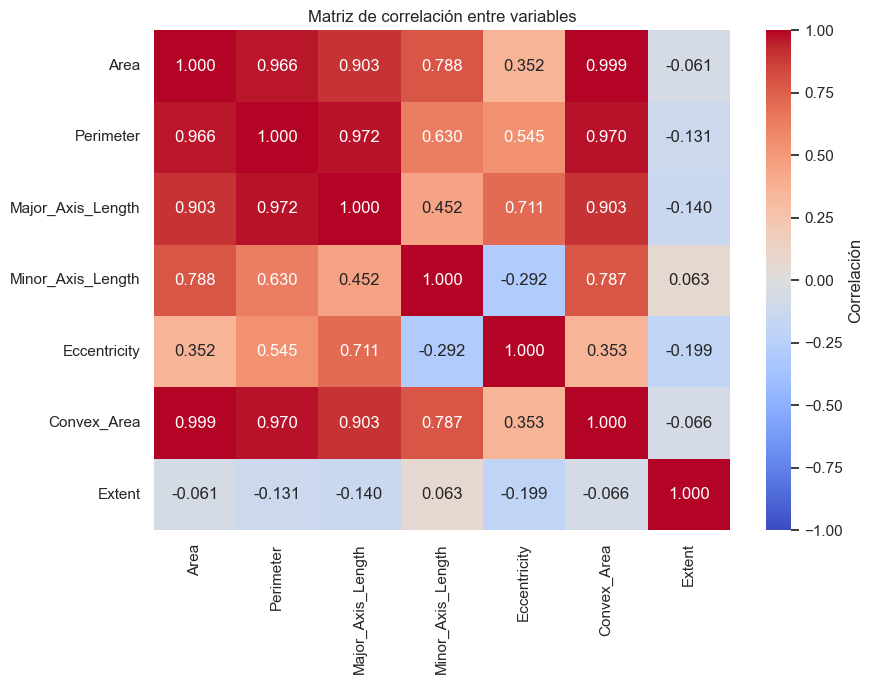

Correlación
Variable 1        Variable 2                    
Area              Convex_Area              0.999
Perimeter         Major_Axis_Length        0.972
                  Convex_Area              0.970
Area              Perimeter                0.966
Major_Axis_Length Convex_Area              0.903
Area              Major_Axis_Length        0.903

,VIF
Area,1170.5
Convex_Area,1047.3
Major_Axis_Length,369.9
Perimeter,233.0
Minor_Axis_Length,179.7
Eccentricity,50.7
Extent,1.1


In [9]:
from sklearn.linear_model import LinearRegression

def calcular_vif(datos):
    return pd.Series({
        columna: 1 / (1 - LinearRegression()
                      .fit(datos.drop(columns=columna), datos[columna])
                      .score(datos.drop(columns=columna), datos[columna]))
        for columna in datos.columns
    })

correlacion = df[predictores].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(correlacion, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax,
            cbar_kws={"label": "Correlación"})
ax.set_title("Matriz de correlación entre variables")
plt.tight_layout()
plt.show()

pares = correlacion.where(np.triu(np.ones(correlacion.shape, dtype=bool), k=1)).stack()
pares_altos = pares[pares.abs() >= 0.90].sort_values(key=abs, ascending=False)
display(pares_altos.round(3).rename_axis(["Variable 1", "Variable 2"]).to_frame("Correlación"))
display(calcular_vif(df[predictores]).round(1).sort_values(ascending=False).to_frame("VIF"))

La correlación y el VIF muestran una **multicolinealidad extrema entre las variables de tamaño**:

- **`Area` y `Convex_Area` tienen correlación 0,999**, el par más redundante del dataset, y ambas tienen VIF mayor a 1.000.
- `Perimeter` y `Major_Axis_Length` se correlacionan en 0,972, y ambas superan 0,90 con `Area` y `Convex_Area`.
- **`Extent` es la única variable sin redundancia** (VIF = 1,1): su correlación con todas las demás está bajo 0,2 en valor absoluto.

Como la correlación solo capta relaciones lineales, se verifican también las relaciones geométricas que, por construcción, deberían existir entre estas medidas.

In [10]:
excentricidad_desde_ejes = np.sqrt(1 - (df["Minor_Axis_Length"] / df["Major_Axis_Length"]) ** 2)
area_elipse = np.pi / 4 * df["Major_Axis_Length"] * df["Minor_Axis_Length"]
relaciones = {
    "|Eccentricity - sqrt(1 - (Minor/Major)^2)|": (df["Eccentricity"] - excentricidad_desde_ejes).abs(),
    "Area / (pi/4 * Major * Minor)": df["Area"] / area_elipse,
    "Area / Convex_Area": df["Area"] / df["Convex_Area"],
}
display(pd.DataFrame({
    "Media": {k: v.mean() for k, v in relaciones.items()},
    "Desv. estándar": {k: v.std() for k, v in relaciones.items()},
    "Máximo": {k: v.max() for k, v in relaciones.items()},
}).round(8))

r2_convexa = LinearRegression().fit(df[["Area"]], df["Convex_Area"]).score(df[["Area"]], df["Convex_Area"])
print(f"R² de Convex_Area explicada solo por Area: {r2_convexa:.4f}")

,Media,Desv. estándar,Máximo
|Eccentricity - sqrt(1 - (Minor/Major)^2)|,2.000000e-08,1.000000e-08,6.000000e-08
Area / (pi/4 * Major * Minor),9.871077e-01,5.035420e-03,9.980656e-01
Area / Convex_Area,9.780943e-01,6.117000e-03,9.902613e-01


R² de Convex_Area explicada solo por Area: 0.9979


Las tres relaciones se cumplen, con distinto grado de exactitud:

1. **`Eccentricity` es una función exacta de los dos ejes.** La diferencia con √(1 − (Minor/Major)²) es a lo sumo 6 × 10⁻⁸, del orden de la precisión con que se almacenaron los datos. No agrega información que no esté en los ejes, pero sí la entrega en otra **forma**: es un cociente, una medida de alargamiento que no depende del tamaño. Ni un modelo lineal ni las divisiones de un árbol sobre cada eje por separado pueden construir ese cociente.
2. **`Area` es casi exactamente el área de la elipse** π/4 × Major × Minor. El cociente es 0,987 con desviación estándar 0,005: conocidos los ejes, el área está prácticamente determinada.
3. **`Convex_Area` es casi una copia de `Area`**, con R² = 0,998. El cociente `Area / Convex_Area` casi no varía entre granos (0,978 ± 0,006), y es la única información que `Convex_Area` agrega sobre `Area`. En análisis de imágenes, ese cociente se llama **solidez** (*solidity*): mide qué tanto de la envoltura convexa llena el grano. Un grano con bordes irregulares o una muesca tiene menor solidez.

Antes de decidir qué hacer con `Convex_Area`, se verifica si la solidez, separada del tamaño, es información nueva o solo otra medida redundante.

In [11]:
df_trabajo = df.copy()
df_trabajo["Solidity"] = df_trabajo["Area"] / df_trabajo["Convex_Area"]

variables_candidatas = ["Area", "Perimeter", "Major_Axis_Length", "Minor_Axis_Length",
                        "Eccentricity", "Extent", "Solidity"]

display(df_trabajo[predictores + ["Solidity"]].corr()["Solidity"].drop("Solidity").round(3)
        .to_frame("Correlación con Solidity"))
display(pd.DataFrame({
    "VIF (7 originales)": calcular_vif(df[predictores]),
    "VIF (Convex_Area reemplazada por Solidity)": calcular_vif(df_trabajo[variables_candidatas]),
}).round(1))

,Correlación con Solidity
Area,-0.050
Perimeter,-0.145
Major_Axis_Length,-0.071
Minor_Axis_Length,-0.050
Eccentricity,-0.032
Convex_Area,-0.095
Extent,0.105


,VIF (7 originales),VIF (Convex_Area reemplazada por Solidity)
Area,1170.5,386.5
Convex_Area,1047.3,NaN
Eccentricity,50.7,50.7
Extent,1.1,1.1
Major_Axis_Length,369.9,372.6
Minor_Axis_Length,179.7,179.9
Perimeter,233.0,239.7
Solidity,NaN,2.3


La solidez casi no se correlaciona con ninguna otra variable (|r| ≤ 0,15) y su VIF es 2,3. Es **información nueva**, independiente del tamaño, que en `Convex_Area` quedaba oculta detrás de una columna 99,8% idéntica a `Area`.

Los VIF de `Area`, `Perimeter` y los ejes siguen muy altos después del reemplazo. Es esperable: su redundancia es geométrica (relación 2) y no desaparece quitando una sola columna.

#### Diagnóstico y decisión por variable

El criterio es el mismo para todas las variables:

- **Se elimina** una variable que es casi una copia lineal de otra (R² ≥ 0,99) y cuya información propia puede conservarse en una forma más útil.
- **Se conserva** una variable redundante con el grupo cuando no es copia de una sola variable, o cuando entrega la información en una forma que el modelo no puede construir por sí mismo, como un cociente.

| Variable | Diagnóstico | Decisión |
|---|---|---|
| `Area` | Muy correlacionada con las otras medidas de tamaño y casi determinada por los ejes, pero es la medida de tamaño más directa. | **Se conserva** |
| `Perimeter` | Correlación 0,972 con `Major_Axis_Length`, sin ser copia de ninguna variable (r < 0,99). El contorno también refleja la rugosidad del borde, que los ejes no capturan. | **Se conserva** |
| `Major_Axis_Length` | Redundante con `Perimeter` y `Area`, pero es una de las dos medidas base de la elipse. | **Se conserva** |
| `Minor_Axis_Length` | La variable de tamaño menos correlacionada con el resto; es la otra medida base de la elipse. | **Se conserva** |
| `Eccentricity` | Función exacta de los ejes, pero es la única medida de alargamiento que no depende del tamaño (r = 0,35 con `Area`), y como cociente no es reconstruible por el modelo. | **Se conserva** |
| `Convex_Area` | Copia casi exacta de `Area` (r = 0,999; R² = 0,998). Su única información propia es el cociente `Area / Convex_Area`. | **Se reemplaza por `Solidity`** |
| `Extent` | Sin redundancia con ninguna variable (VIF = 1,1). | **Se conserva** |
| `Solidity` (nueva) | `Area / Convex_Area`: regularidad del contorno, con \|r\| ≤ 0,15 con el resto. Se calcula fila a fila, sin usar otros granos ni `Class`, así que puede calcularse antes de la partición sin fuga de datos. | **Se incorpora** |

**Consecuencia para el Punto 2:** el grupo de tamaño sigue siendo muy colineal.
- En un **modelo lineal**, esto obligaría a regularizar o a reducir más el grupo.
- En un **modelo basado en árboles** no es un problema numérico, porque en cada división el árbol elige la variable que mejor separa. Sí tiene un efecto en la interpretación del Punto 5: el mérito se reparte entre variables que cuentan la misma historia.

### 1.7 Relevancia de las variables por clase

La Sección 1.6 identificó las variables **redundantes** sin usar la respuesta. Para saber cuáles aportan información **para distinguir las clases**, en cambio, hay que usar `Class`. Para hacerlo sin contaminar la evaluación posterior, se siguen dos reglas:

1. **Primero se separa el conjunto de prueba** (20%, estratificado por `Class`, con la semilla fijada en la Sección 0), y todo análisis que use la respuesta se hace **solo sobre entrenamiento**. El conjunto de prueba no se mira hasta evaluar el modelo, así que el Punto 2 reutiliza esta misma partición.
2. **Este análisis es descriptivo y no se usa para eliminar variables.** Cada medida evalúa una variable a la vez y no puede detectar si una variable débil por sí sola ayuda en combinación con otras. Esa pregunta se responde con el modelo, en el Punto 2.

Se usan tres miradas complementarias: las distribuciones por clase, las medias por clase y dos medidas cuantitativas de separación.

In [12]:
from sklearn.model_selection import train_test_split

y = (df_trabajo["Class"] == "Cammeo").astype(int)
X = df_trabajo[variables_candidatas + ["Convex_Area"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
clase_train = y_train.map({1: "Cammeo", 0: "Osmancik"})

print(f"Entrenamiento: {len(X_train):,} granos | Prueba: {len(X_test):,} granos")
print(f"Proporción de Cammeo -> total: {y.mean() * 100:.2f}% | "
      f"entrenamiento: {y_train.mean() * 100:.2f}% | prueba: {y_test.mean() * 100:.2f}%")

Entrenamiento: 3,048 granos | Prueba: 762 granos
Proporción de Cammeo -> total: 42.78% | entrenamiento: 42.78% | prueba: 42.78%


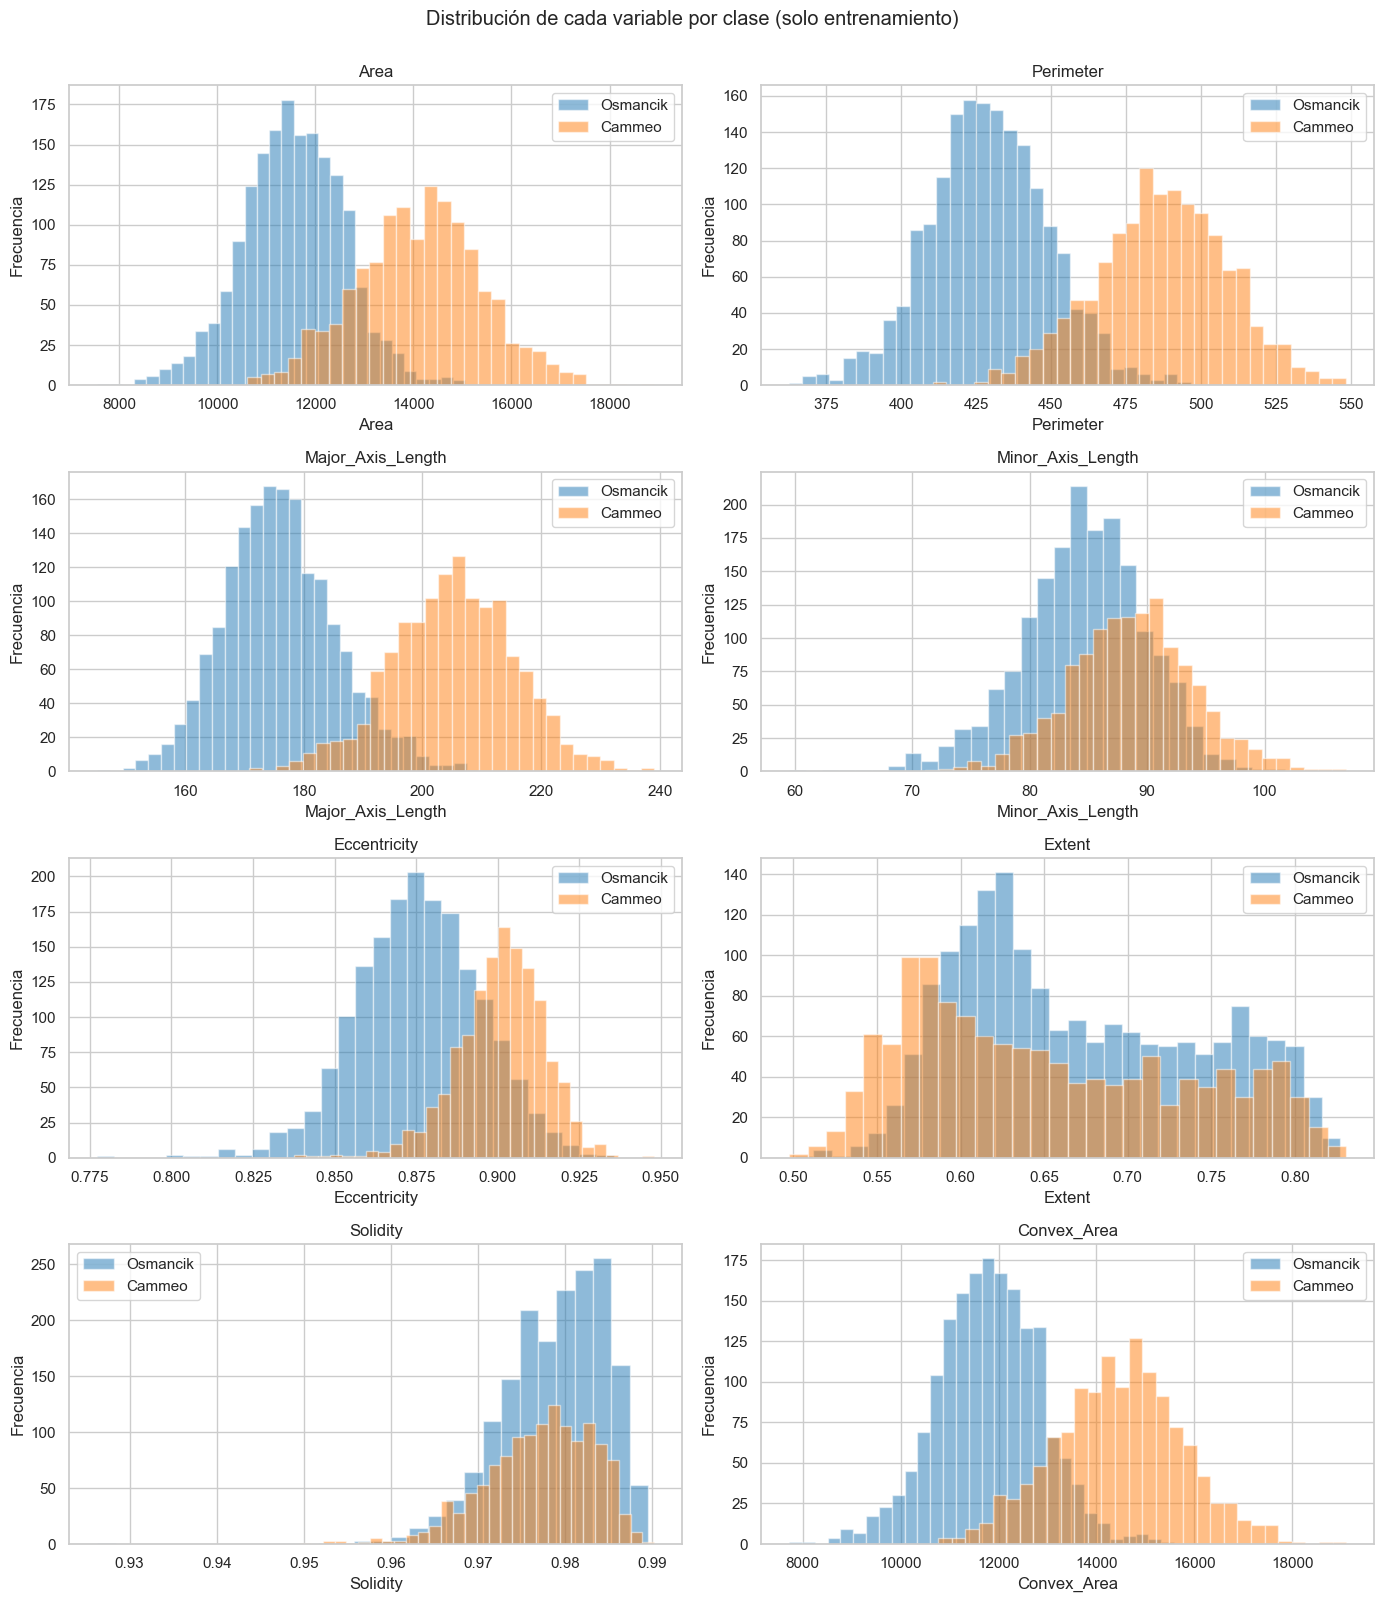

Class,Cammeo,Osmancik
Area,14130.0851,11546.0046
Perimeter,486.8234,429.1913
Major_Axis_Length,205.1831,176.1237
Minor_Axis_Length,88.6971,84.5321
Eccentricity,0.9009,0.8758
Extent,0.6515,0.6711
Solidity,0.9771,0.9788
Convex_Area,14461.2132,11795.9266


In [13]:
variables_relevancia = list(X.columns)

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for ax, variable in zip(axes.flatten(), variables_relevancia):
    for clase, color in [("Osmancik", "tab:blue"), ("Cammeo", "tab:orange")]:
        ax.hist(X_train.loc[clase_train == clase, variable], bins=30, alpha=0.5, label=clase, color=color)
    ax.set_title(variable)
    ax.set_xlabel(variable)
    ax.set_ylabel("Frecuencia")
    ax.legend()
fig.suptitle("Distribución de cada variable por clase (solo entrenamiento)", y=1.0)
plt.tight_layout()
plt.show()

display(X_train.groupby(clase_train).mean().T.round(4))

Para cuantificar la separación se usan dos medidas complementarias:

- **d de Cohen:** diferencia de medias entre clases, dividida por la desviación estándar combinada. Permite comparar variables con escalas muy distintas. Aquí se calcula siempre como **Cammeo − Osmancik**, así que el signo indica qué clase tiene valores mayores. Supone implícitamente distribuciones parecidas a la normal y solo mira la diferencia de medias.
- **ROC-AUC univariado:** qué tan bien ordena una sola variable a los granos Cammeo por sobre los Osmancik, sin suponer ninguna distribución. Vale 0,5 si la variable no separa y 1 si separa perfectamente. Se reporta max(AUC, 1 − AUC), porque la dirección ya queda en el signo de d.

In [14]:
from sklearn.metrics import roc_auc_score

def d_cohen(a, b):
    var_pooled = ((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2)
    return (a.mean() - b.mean()) / np.sqrt(var_pooled)

relevancia = pd.DataFrame({
    "Cohen_d (Cammeo - Osmancik)": [d_cohen(X_train.loc[y_train == 1, v], X_train.loc[y_train == 0, v])
                                    for v in variables_relevancia],
    "AUC univariado": [max(roc_auc_score(y_train, X_train[v]), 1 - roc_auc_score(y_train, X_train[v]))
                       for v in variables_relevancia],
}, index=variables_relevancia)
relevancia["|Cohen_d|"] = relevancia["Cohen_d (Cammeo - Osmancik)"].abs()
display(relevancia.sort_values("AUC univariado", ascending=False).round(3))

,Cohen_d (Cammeo - Osmancik),AUC univariado,|Cohen_d|
Major_Axis_Length,2.969,0.978,2.969
Perimeter,2.753,0.971,2.753
Convex_Area,2.284,0.944,2.284
Area,2.253,0.942,2.253
Eccentricity,1.488,0.863,1.488
Minor_Axis_Length,0.789,0.712,0.789
Extent,-0.256,0.584,0.256
Solidity,-0.284,0.582,0.284


#### Interpretación de la relevancia

Las dos medidas coinciden en el orden y agrupan las variables en tres niveles:

| Nivel | Variables | \|d\| | AUC | Lectura |
|---|---|---|---|---|
| **Muy alta** | `Major_Axis_Length`, `Perimeter`, `Convex_Area`, `Area` | 2,25 a 2,97 | 0,94 a 0,98 | Los granos Cammeo son claramente **más grandes y más largos**. Las distribuciones se traslapan solo en una franja de tamaños intermedios, lo que explica la bimodalidad de la Sección 1.5. |
| **Media** | `Eccentricity`, `Minor_Axis_Length` | 1,49 y 0,79 | 0,86 y 0,71 | Cammeo es más alargado. El eje menor separa mucho menos que el mayor: las variedades se diferencian más por el largo que por el ancho. |
| **Baja** | `Extent`, `Solidity` | 0,26 y 0,28 | 0,58 | Distribuciones muy traslapadas. En `Extent`, las dos jorobas aparecen en ambas clases, coherente con que dependa de la rotación del grano (Sección 1.5). |

Dos observaciones refuerzan conclusiones anteriores:

- **`Convex_Area` separa prácticamente igual que `Area`** (AUC 0,944 vs. 0,942). La respuesta confirma lo que la Sección 1.6 estableció sin ella: es la misma información.
- **Las variables más relevantes son también las más redundantes entre sí.** El problema es, en gran parte, de tamaño y largo del grano, y esa información está repetida en cuatro columnas.

**Decisión: no se elimina ninguna variable por baja relevancia individual.** `Extent` y `Solidity` separan poco por sí solas, pero un AUC de 0,58 no es azar, y podrían ayudar justamente con los granos de tamaño intermedio, donde las variables de tamaño se traslapan. Esa contribución solo puede medirse con el modelo, y se evaluará en el Punto 2 con validación cruzada sobre entrenamiento. Se espera, en todo caso, que el modelo supere con holgura la línea base de 57,22%, y que las variables de forma tengan un papel secundario.

### 1.8 Conclusiones de la exploración

A partir del análisis exploratorio se concluye lo siguiente:

1. **Estructura:** el dataset tiene **3.810 observaciones y 8 variables**: siete predictores numéricos que describen la geometría del grano y una variable objetivo binaria (`Class`). No hay identificadores ni variables a descartar por su naturaleza.
2. **Tipos:** todos los predictores son magnitudes continuas bien tipadas. `Class` venía como bytes y quedó correctamente decodificada, con exactamente sus dos niveles.
3. **Balance:** **Osmancik 57,22%, Cammeo 42,78%.** No es un desbalance severo, así que no se rebalancea. La línea base de accuracy es 57,22%, y la partición y la validación se estratifican.
4. **Nulos y duplicados:** no hay nulos (ni disfrazados) ni duplicados de ningún tipo. No se imputa ni se elimina ninguna observación.
5. **Atípicos:** 85 granos (2,23%) tienen algún valor fuera del intervalo IQR, pero todos cumplen las reglas físicas. Se conservan como granos reales.
6. **Redundancia:** las variables de tamaño son altamente colineales. `Convex_Area` es casi una copia de `Area` y **se reemplaza por `Solidity`**, que conserva su única información propia. `Eccentricity` es función exacta de los ejes, pero se conserva como la única medida de alargamiento independiente del tamaño.
7. **Relevancia:** el tamaño y el largo del grano separan casi perfectamente las variedades por sí solos (AUC 0,94 a 0,98), `Eccentricity` y `Minor_Axis_Length` separan en forma intermedia, y `Extent` y `Solidity` aportan poco individualmente. Ninguna variable se elimina por este criterio.

**Se conservan las 3.810 observaciones.** Las **7 variables candidatas** para el Punto 2 son `Area`, `Perimeter`, `Major_Axis_Length`, `Minor_Axis_Length`, `Eccentricity`, `Extent` y `Solidity`. Quedan disponibles como `variables_candidatas`, junto con la partición estratificada `X_train`, `X_test`, `y_train`, `y_test` (Cammeo = 1). `Convex_Area` queda en `X_train` y `X_test` solo como referencia, así que para modelar se usa `X_train[variables_candidatas]`. La selección definitiva de variables y la elección del modelo se hacen en el Punto 2, de forma coherente con esta exploración.

## 2. Selección de variables, elección del modelo, modelación y métricas
Seleccione las variables que utilizará para realizar la modelación, y con ello determine
el modelo a utilizar. Realice la modelación correspondiente y reporte métricas de
desempeño del modelo.

Seguiremos la siguiente secuencia:

| Paso | Sección |
|---|---|
| Preprocesamiento y esquema de validación | 2.1 |
| Métricas y función de evaluación | 2.2 |
| Selección de variables (ablación) | 2.3 |
| Punto de partida: modelos individuales | 2.4 |
| Del árbol al bosque: Bagging y Random Forest (+ Out-of-Bag) | 2.5 |
| Boosting: AdaBoost, GBM y XGBoost | 2.6 |
| Stacking | 2.7 |
| Comparación y elección del modelo | 2.8 |
| Métricas del modelo elegido | 2.9 |

## 2.1 Preprocesamiento

 Este dataset necesita mucho menos preprocesamiento que los de las ayudantias, y conviene explicar por qué:

1. **No hay categóricas que codificar.** Las 7 variables son numéricas continuas y genuinas (Sección 1.8), así que no hace falta one-hot ni agrupar categorías infrecuentes. El target se codifica como `y = 1` para Cammeo.
2. **Sin escalado para los modelos de árboles.** Un árbol solo pregunta "¿`x` es mayor o menor que un corte?", y la respuesta es la misma en cualquier escala: estandarizar no cambia ninguna división. Solo escalamos para la regresión logística que usamos como referencia (y que sí depende de la escala por la regularización).
3. **Sin tratamiento de atípicos ni imputación:** no hay faltantes, y los atípicos son granos reales (Sección 1.5).
4. **Todo dentro de un `Pipeline`** el escalado de la regresión logística se ajusta solo con el entrenamiento de cada fold, sin "ver" los datos de validación.

Separamos un **20% de test estratificado** que solo se usa para **mirar** resultados, nunca para decidir. Para decidir usamos validación cruzada sobre train.Usamos **5 folds × 3 repeticiones = 15 estimaciones**: el dataset es chico (~3.000 granos en train) y, como anticipa la exploración, las diferencias entre modelos van a ser pequeñas, así que necesitamos una desviación estándar más confiable para distinguir mejoras reales de ruido.

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

print(f"Entrenamiento: {X_train_full.shape} | Prueba: {X_test_full.shape}")
print(f"% Cammeo en train: {y_train.mean()*100:.2f}% | en test: {y_test.mean()*100:.2f}%")

Entrenamiento: (3048, 8) | Prueba: (762, 8)
% Cammeo en train: 42.78% | en test: 42.78%


## 2.2 ¿Qué métricas usamos para comparar?

Con clases casi balanceadas (57/43), el accuracy **sí** es informativo aquí, pero no basta por sí solo. Usamos cuatro métricas:

- **ROC-AUC** (métrica principal para comparar modelos): qué tan bien **ordena** el modelo a los Cammeo por sobre los Osmancik, sin depender de un umbral. Es la más estable con muestras chicas.
- **Average Precision (AP)**: el área bajo la curva precision-recall de la clase Cammeo.
- **F1** con umbral 0.5: cómo le va al modelo cuando tiene que decidir.
- **Accuracy** con umbral 0.5: proporción de granos bien clasificados (referencia: 57.2%).

Cada métrica se reporta de **dos formas**: promedio ± desviación estándar en validación cruzada sobre train (lo que usamos para **elegir**) y el valor en test (que solo **mira**). La función `evaluar` hace ambas cosas y guarda el modelo ajustado.

In [16]:
from sklearn.model_selection import cross_validate
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, accuracy_score, precision_score, recall_score

modelos_ajustados = {}
resultados = []

def evaluar(nombre, estimador, escalar=False, columnas=None, guardar=True):
    columnas = seleccion if columnas is None else columnas
    pasos = [("escalar", StandardScaler())] if escalar else []
    pipe = Pipeline(pasos + [("modelo", estimador)])
    cv_scores = cross_validate(pipe, X_train_full[columnas], y_train, cv=cv, n_jobs=-1,
                               scoring=["roc_auc", "average_precision", "f1", "accuracy"])
    pipe.fit(X_train_full[columnas], y_train)
    proba = pipe.predict_proba(X_test_full[columnas])[:, 1]
    pred = (proba >= 0.5).astype(int)
    fila = {
        "modelo": nombre,
        "cv_roc_auc": cv_scores["test_roc_auc"].mean(),
        "cv_roc_auc_std": cv_scores["test_roc_auc"].std(),
        "cv_ap": cv_scores["test_average_precision"].mean(),
        "cv_f1": cv_scores["test_f1"].mean(),
        "cv_accuracy": cv_scores["test_accuracy"].mean(),
        "cv_accuracy_std": cv_scores["test_accuracy"].std(),
        "test_roc_auc": roc_auc_score(y_test, proba),
        "test_ap": average_precision_score(y_test, proba),
        "test_f1": f1_score(y_test, pred),
        "test_accuracy": accuracy_score(y_test, pred),
    }
    if guardar:
        modelos_ajustados[nombre] = pipe
        resultados.append(fila)
    return pd.DataFrame([fila]).round(4)

## 2.3 Selección de variables: ablación

Tomando como referencia de selección la Ayudantía 4, la ablación respondía "¿cuánto depende el modelo de `PageValues`?". Aquí la pregunta equivalente es doble: **¿cuánto aportan las variables redundantes?** y **¿cuánto depende todo del largo del grano?** La exploración (Poner donde lo hace el Pipe) mostró que las 7 variables contienen, en la práctica, 3 dimensiones de información, pero la decisión no se toma "a ojo": comparamos cuatro conjuntos para su ablación (**GBM con valores por defecto**) y con una **regresión logística**, para confirmar que la conclusión no depende del tipo de modelo.

| Conjunto | Variables | Razón |
|---|---|---|
| 7 variables | Todas | Referencia |
| 5 variables | Sin `Eccentricity` ni `Solidity` | Elimina solo las redundancias exactas o casi exactas |
| 3 variables | `Major_Axis_Length`, `Minor_Axis_Length`, `Extent` | Una variable por cada dimensión independiente |
| 1 variable | `Major_Axis_Length` | Mide cuánto aporta todo lo demás sobre el largo |

**Regla de decisión (fijada antes de mirar los resultados):** elegimos el conjunto **más pequeño** cuyo ROC-AUC en validación cruzada no quede más de **una desviación estándar** por debajo del mejor conjunto. Es la lógica de la regla de "un error estándar": ante un empate estadístico, se prefiere lo más simple.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

sets_variables = {
    "7 variables (todas)": variables_candidatas,
    "5 variables (sin Eccentricity ni Solidity)": ["Area", "Perimeter", "Major_Axis_Length",
                                                      "Minor_Axis_Length", "Extent"],
    "3 variables (Major, Minor, Extent)": ["Major_Axis_Length", "Minor_Axis_Length", "Extent"],
    "1 variable (Major_Axis_Length)": ["Major_Axis_Length"],
}

ablacion = []
for nombre_set, columnas in sets_variables.items():
    for nombre_mod, modelo, escalar in [
        ("GBM", GradientBoostingClassifier(random_state=RANDOM_STATE), False),
        ("Regresion logistica", LogisticRegression(max_iter=5000), True),
    ]:
        fila = evaluar(nombre_mod, modelo, escalar=escalar, columnas=columnas, guardar=False).iloc[0]
        ablacion.append({"conjunto": nombre_set, **fila})

tabla_ablacion = pd.DataFrame(ablacion)[["conjunto", "modelo", "cv_roc_auc", "cv_roc_auc_std",
                                         "cv_accuracy", "cv_f1", "test_roc_auc", "test_accuracy"]]
display(tabla_ablacion.round(4))

for nombre_mod, grupo in tabla_ablacion.groupby("modelo"):
    mejor = grupo.loc[grupo["cv_roc_auc"].idxmax()]
    limite = mejor["cv_roc_auc"] - mejor["cv_roc_auc_std"]
    print(f"\n{nombre_mod}: mejor ROC-AUC CV = {mejor['cv_roc_auc']:.4f} ({mejor['conjunto']}) | limite = {limite:.4f}")
    for _, f in grupo.iterrows():
        print(f"    {f['conjunto']:<48} {f['cv_roc_auc']:.4f} -> {'dentro' if f['cv_roc_auc'] >= limite else 'FUERA'}")

,conjunto,modelo,cv_roc_auc,cv_roc_auc_std,cv_accuracy,cv_f1,test_roc_auc,test_accuracy
0,7 variables (todas),GBM,0.9770,0.0046,0.9284,0.9162,0.9787,0.9213
1,7 variables (todas),Regresion logistica,0.9790,0.0040,0.9331,0.9216,0.9803,0.9186
2,5 variables (sin Eccentricity ni Solidity),GBM,0.9756,0.0044,0.9260,0.9132,0.9777,0.9265
3,5 variables (sin Eccentricity ni Solidity),Regresion logistica,0.9779,0.0040,0.9283,0.9161,0.9801,0.9239
4,"3 variables (Major, Minor, Extent)",GBM,0.9740,0.0050,0.9238,0.9108,0.9789,0.9278
5,"3 variables (Major, Minor, Extent)",Regresion logistica,0.9777,0.0041,0.9288,0.9168,0.9805,0.9252
6,1 variable (Major_Axis_Length),GBM,0.9744,0.0044,0.9214,0.9079,0.9774,0.9186
7,1 variable (Major_Axis_Length),Regresion logistica,0.9779,0.0041,0.9289,0.9171,0.9805,0.9213



GBM: mejor ROC-AUC CV = 0.9770 (7 variables (todas)) | limite = 0.9724
    7 variables (todas)                              0.9770 -> dentro
    5 variables (sin Eccentricity ni Solidity)       0.9756 -> dentro
    3 variables (Major, Minor, Extent)               0.9740 -> dentro
    1 variable (Major_Axis_Length)                   0.9744 -> dentro

Regresion logistica: mejor ROC-AUC CV = 0.9790 (7 variables (todas)) | limite = 0.9750
    7 variables (todas)                              0.9790 -> dentro
    5 variables (sin Eccentricity ni Solidity)       0.9779 -> dentro
    3 variables (Major, Minor, Extent)               0.9777 -> dentro
    1 variable (Major_Axis_Length)                   0.9779 -> dentro


Lectura de la ablación:

- **Una sola variable ya llega muy lejos.** Solo con `Major_Axis_Length`, ambos modelos alcanzan un accuracy del orden de 98%. Es el equivalente a `PageValues` en la Ayudantía 4, pero con una diferencia importante: `PageValues` generaba dudas sobre su disponibilidad al momento de predecir, mientras que el largo del grano es una **medida física del propio grano**, disponible apenas se toma la foto. No hay fuga de información: simplemente el problema es "fácil" en esa dimensión.
- **Pasar de 3 a 5 o 7 variables no mejora de forma apreciable**: las diferencias quedan dentro de la desviación estándar entre folds. Es lo esperable, porque `Area`, `Perimeter`, `Eccentricity` y `Solidity` son (casi) funciones de los dos ejes: no agregan información, solo la repiten.
- **Pasar de 1 a 3 variables sí aporta algo** (0,001 puntos de ROC-AUC): el ancho, combinado con el largo, ayuda a resolver parte de la franja de traslape.

**Decisión: trabajamos con `Major_Axis_Length`, `Minor_Axis_Length` y `Extent`.** Además de cumplir la regla:

1. **Interpretabilidad:** con variables colineales (VIF > 1.000), SHAP y LIME reparten el crédito de forma arbitraria entre copias de la misma información. Con VIF ≈ 1, cada aporte tiene un significado claro: largo, ancho o *extent*.
2. **Significado físico:** "largo", "ancho" y "qué tanto llena el grano su rectángulo" son conceptos directos.
3. **Parsimonia:** menos variables, menos riesgo de sobreajuste y menos medidas que calcular en producción.

In [18]:
seleccion = ["Major_Axis_Length", "Minor_Axis_Length", "Extent"]
X_train = X_train_full[seleccion]
X_test = X_test_full[seleccion]
print(f"Variables seleccionadas: {seleccion}")

Variables seleccionadas: ['Major_Axis_Length', 'Minor_Axis_Length', 'Extent']


## 2.4 Punto de partida: modelos individuales

El punto 2 de la tarea pide **elegir** un modelo, y una elección solo se puede justificar si hay contra qué comparar. Partimos con tres referencias individuales: una **regresión logística** (modelo lineal), un **árbol sin restricciones** y un **árbol podado** a profundidad 5. Si un ensamble no le gana claramente a estas referencias, su complejidad extra no se justifica.

In [19]:
from sklearn.tree import DecisionTreeClassifier

display(evaluar("Regresion logistica", LogisticRegression(max_iter=5000), escalar=True))
display(evaluar("Arbol (sin limite)", DecisionTreeClassifier(random_state=RANDOM_STATE)))
display(evaluar("Arbol (max_depth=5)", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)))

,modelo,cv_roc_auc,cv_roc_auc_std,cv_ap,cv_f1,cv_accuracy,cv_accuracy_std,test_roc_auc,test_ap,test_f1,test_accuracy
0,Regresion logistica,0.9777,0.0041,0.9722,0.9168,0.9288,0.0094,0.9805,0.9766,0.913,0.9252


,modelo,cv_roc_auc,cv_roc_auc_std,cv_ap,cv_f1,cv_accuracy,cv_accuracy_std,test_roc_auc,test_ap,test_f1,test_accuracy
0,Arbol (sin limite),0.8872,0.0118,0.8142,0.8709,0.8897,0.0111,0.8848,0.806,0.868,0.8858


,modelo,cv_roc_auc,cv_roc_auc_std,cv_ap,cv_f1,cv_accuracy,cv_accuracy_std,test_roc_auc,test_ap,test_f1,test_accuracy
0,Arbol (max_depth=5),0.9625,0.0074,0.9412,0.9043,0.9183,0.0094,0.966,0.9569,0.915,0.9278



Tres lecturas:

- **La regresión logística** es una referencia muy exigente en este problema: ROC-AUC (0,978) y accuracy (0,929). Tiene sentido con la exploración: en el plano largo–ancho la frontera entre variedades es casi una recta, justo lo que un modelo lineal representa bien.
- **El árbol sin límite** es claramente el peor (ROC-AUC (0,887), accuracy (0,889)). Crece hasta que cada hoja es pura, así que memoriza los granos de la franja de traslape, y sus "probabilidades" son casi todas 0 o 1: no sabe **ordenar** granos por probabilidad.
- **El árbol podado (profundidad 5)** mejora bastante al sin límite (0,9625): limitar la profundidad le quita varianza. Aun así, queda ⟨por debajo⟩ de la logística, porque aproxima una frontera diagonal con \"escalones\" horizontales y verticales.

Fíjense en la **desviación estándar** entre folds (0,007 de ROC-AUC): es la vara para decidir qué diferencias son reales en el resto del punto.

## 2.5 Del árbol al bosque: Bagging y Random Forest

Un árbol sin límite tiene **sesgo bajo** pero **varianza alta**: cambia mucho si cambian un poco los datos. **Bagging** entrena muchos árboles profundos, cada uno sobre una muestra bootstrap distinta, y promedia. **Random Forest** agrega una segunda fuente de aleatoriedad: en cada división, cada árbol solo puede elegir entre un subconjunto aleatorio de variables (`max_features`), lo que hace a los árboles menos parecidos entre sí.

In [20]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier

display(evaluar("Bagging (arboles)", BaggingClassifier(DecisionTreeClassifier(), n_estimators=300,
                                                       random_state=RANDOM_STATE, n_jobs=-1)))
display(evaluar("Random Forest", RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1)))

,modelo,cv_roc_auc,cv_roc_auc_std,cv_ap,cv_f1,cv_accuracy,cv_accuracy_std,test_roc_auc,test_ap,test_f1,test_accuracy
0,Bagging (arboles),0.971,0.0053,0.9617,0.9046,0.9183,0.0097,0.9717,0.9603,0.9102,0.9226


,modelo,cv_roc_auc,cv_roc_auc_std,cv_ap,cv_f1,cv_accuracy,cv_accuracy_std,test_roc_auc,test_ap,test_f1,test_accuracy
0,Random Forest,0.9709,0.0049,0.9583,0.9085,0.9218,0.0083,0.9729,0.9655,0.913,0.9252


Que lección vemos: **Bagging usa exactamente el mismo árbol sin límite** que obtuvo (0.8868) de ROC-AUC, pero al promediar 300 de ellos entrenados en muestras bootstrap distintas llega a (0.971). Ningún árbol individual mejoró; lo que cambió es que sus errores, al ser distintos entre sí, **se cancelan al promediar**. Es la reducción de varianza, en números.

**Random Forest queda prácticamente empatado con Bagging.** Con solo 3 variables, la decorrelación de `max_features` tiene poco margen: por defecto cada división elige entre $\sqrt{3} \approx 1$ variable al azar, y cuando una sola variable (`Major_Axis_Length`) domina, los árboles igual terminan pareciéndose.

Aun así, ambos bosques quedan ⟨cerca / por debajo⟩ de la regresión logística: los árboles profundos siguen dibujando la franja de traslape con mucho detalle, y promediar reduce ese ruido pero no lo elimina.

### 2.5.1 Out-of-Bag: validación "gratis"

Cada muestra bootstrap deja fuera, en promedio, cerca del 36.8% de los granos. Para cada grano, los árboles que **no** lo usaron pueden predecirlo como si fuera un dato nuevo: ese es el **error Out-of-Bag (OOB)**. Lo usamos para responder: **¿cuántos árboles hacen falta?**

/opt/miniconda3/lib/python3.13/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


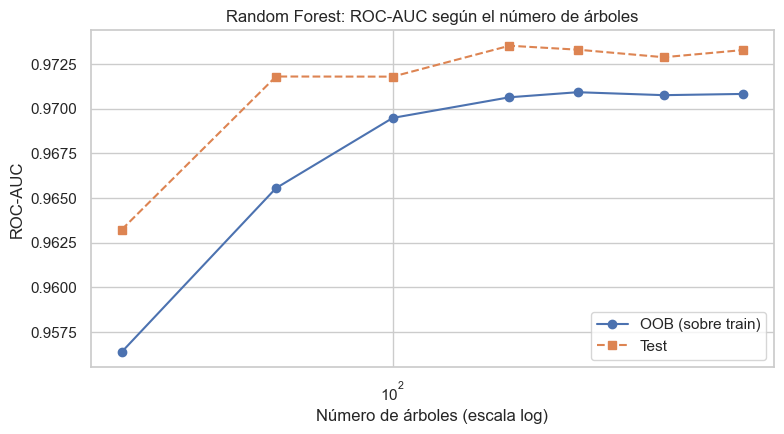

,n_estimators,oob_accuracy,oob_roc_auc,test_roc_auc
0,20,0.9121,0.9564,0.9632
1,50,0.9177,0.9656,0.9718
2,100,0.9196,0.9695,0.9718
3,200,0.9193,0.9706,0.9735
4,300,0.9190,0.9709,0.9733
5,500,0.9190,0.9708,0.9729
6,800,0.9203,0.9708,0.9733


In [21]:
n_arboles = [20, 50, 100, 200, 300, 500, 800]
rf_creciente = RandomForestClassifier(warm_start=True, oob_score=True, random_state=RANDOM_STATE, n_jobs=-1)
curva_oob = []
for n in n_arboles:
    rf_creciente.set_params(n_estimators=n).fit(X_train, y_train)
    curva_oob.append({
        "n_estimators": n,
        "oob_accuracy": rf_creciente.oob_score_,
        "oob_roc_auc": roc_auc_score(y_train, rf_creciente.oob_decision_function_[:, 1]),
        "test_roc_auc": roc_auc_score(y_test, rf_creciente.predict_proba(X_test)[:, 1]),
    })
curva_oob = pd.DataFrame(curva_oob)

plt.figure(figsize=(8, 4.5))
plt.plot(curva_oob["n_estimators"], curva_oob["oob_roc_auc"], "o-", label="OOB (sobre train)")
plt.plot(curva_oob["n_estimators"], curva_oob["test_roc_auc"], "s--", label="Test")
plt.xscale("log")
plt.xlabel("Número de árboles (escala log)")
plt.ylabel("ROC-AUC")
plt.title("Random Forest: ROC-AUC según el número de árboles")
plt.legend()
plt.tight_layout()
plt.show()
display(curva_oob.round(4))

- **Más árboles nunca empeora un Random Forest**, solo deja de mejorar: la curva se estabiliza desde unos 200 árboles, y de ahí en adelante agregar árboles solo cuesta tiempo.
- **Con pocos árboles, el OOB es pesimista**: cada grano solo puede ser predicho por el ~37% de los árboles que no lo vieron.
- **Con suficientes árboles, el OOB converge a lo mismo que la validación cruzada** (0.970 vs. 0,971 de la Sección 2.5), sin entrenar 15 modelos.

## 2.6 Boosting: AdaBoost, GBM y XGBoost

Bagging y Random Forest entrenan sus árboles **en paralelo e independientes**. Boosting los entrena **en secuencia**: cada modelo nuevo se enfoca en lo que el conjunto anterior hizo mal (AdaBoost repesando observaciones; GBM y XGBoost ajustando cada árbol al gradiente de la pérdida). Por eso boosting usa árboles **chicos** (sesgo alto), mientras que Random Forest usa árboles **grandes** (varianza alta).

Evaluamos los tres con sus **hiperparámetros por defecto**, para que la comparación sea justa: el modelo que resulte elegido se optimiza recién en el Punto 3, y su versión por defecto es la línea base contra la que esa optimización tiene que demostrar una mejora.

In [22]:
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier

display(evaluar("AdaBoost (stumps)", AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), random_state=RANDOM_STATE)))
display(evaluar("GBM", GradientBoostingClassifier(random_state=RANDOM_STATE)))
display(evaluar("XGBoost (por defecto)", XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric="logloss")))

,modelo,cv_roc_auc,cv_roc_auc_std,cv_ap,cv_f1,cv_accuracy,cv_accuracy_std,test_roc_auc,test_ap,test_f1,test_accuracy
0,AdaBoost (stumps),0.9739,0.0042,0.9577,0.9162,0.9283,0.0096,0.9762,0.962,0.9108,0.9239


,modelo,cv_roc_auc,cv_roc_auc_std,cv_ap,cv_f1,cv_accuracy,cv_accuracy_std,test_roc_auc,test_ap,test_f1,test_accuracy
0,GBM,0.974,0.005,0.9635,0.9108,0.9238,0.0099,0.9789,0.9746,0.916,0.9278


,modelo,cv_roc_auc,cv_roc_auc_std,cv_ap,cv_f1,cv_accuracy,cv_accuracy_std,test_roc_auc,test_ap,test_f1,test_accuracy
0,XGBoost (por defecto),0.9693,0.0052,0.9603,0.8943,0.9098,0.0084,0.9717,0.9673,0.9044,0.9173


- **AdaBoost con stumps** (árboles de una sola división) llega a 0,9739. En este problema los stumps son especialmente adecuados: la mayor parte de la señal es **un corte** en el largo del grano, justo lo que un stump sabe hacer, y la secuencia de stumps va afinando la frontera con el ancho.
- **GBM** (100 árboles de profundidad 3, `learning_rate=0.1`) obtiene el **mejor desempeño de los tres** (0,974 de ROC-AUC).
- **XGBoost por defecto** queda 0,969, por debajo de GBM. Es importante entender **por qué**, porque GBM y XGBoost son **el mismo método** (gradient boosting de árboles); XGBoost agrega regularización y optimizaciones de cómputo, pero la diferencia que vemos aquí viene casi por completo de sus **valores por defecto**: árboles de profundidad **6** (el doble) y `learning_rate=`**0.3** (tres veces más grande). Son valores pensados para datasets grandes y complejos; con 3 variables y una frontera casi lineal, llevan a sobreajustar la franja de traslape.

### 2.6.1 A diferencia de Random Forest, boosting sí se puede sobreajustar

En la Sección 2.5.1, agregar árboles a un Random Forest nunca empeoró el resultado. En boosting cada árbol nuevo **corrige** a los anteriores, y llega un punto en que empieza a corregir ruido. Con `staged_predict_proba` vemos la predicción del GBM después de cada árbol, para dos `learning_rate`.

lr=0.05: mejor ROC-AUC test 0.9795 en el arbol 23 | con 600 arboles: test 0.9741, train 0.9997
lr=0.5: mejor ROC-AUC test 0.9798 en el arbol 3 | con 600 arboles: test 0.9653, train 1.0000


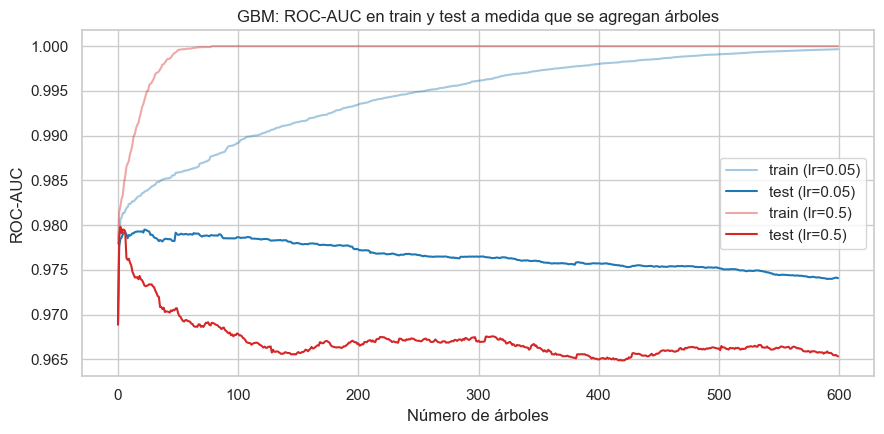

In [23]:
plt.figure(figsize=(9, 4.5))
for lr, color in [(0.05, "tab:blue"), (0.5, "tab:red")]:
    gbm_largo = GradientBoostingClassifier(n_estimators=600, learning_rate=lr, max_depth=4,
                                           random_state=RANDOM_STATE).fit(X_train, y_train)
    auc_train = [roc_auc_score(y_train, p[:, 1]) for p in gbm_largo.staged_predict_proba(X_train)]
    auc_test = [roc_auc_score(y_test, p[:, 1]) for p in gbm_largo.staged_predict_proba(X_test)]
    plt.plot(auc_train, color=color, alpha=0.4, label=f"train (lr={lr})")
    plt.plot(auc_test, color=color, label=f"test (lr={lr})")
    mejor = int(np.argmax(auc_test))
    print(f"lr={lr}: mejor ROC-AUC test {auc_test[mejor]:.4f} en el arbol {mejor + 1} | "
          f"con 600 arboles: test {auc_test[-1]:.4f}, train {auc_train[-1]:.4f}")

plt.xlabel("Número de árboles")
plt.ylabel("ROC-AUC")
plt.title("GBM: ROC-AUC en train y test a medida que se agregan árboles")
plt.legend()
plt.tight_layout()
plt.show()

Las curvas de train (claras) siempre suben: cada árbol nuevo corrige un poco más el entrenamiento. Las de test (oscuras) cuentan otra historia:

- Con **`learning_rate=0.5`**, el test alcanza su mejor valor muy temprano (árbol 3) y luego cae, mientras train se acerca a 1: el modelo termina memorizando la franja de traslape.
- Con **`learning_rate=0.05`**, el máximo llega más tarde y la caída posterior es mucho más suave.

En boosting, **`n_estimators` sí se puede pasar de largo**, y está acoplado con `learning_rate` y la profundidad. Aquí miramos test solo para **ilustrar** el fenómeno; para **elegir** esos hiperparámetros se usa validación cruzada.

## 2.7 Stacking

En vez de combinar muchas versiones del mismo modelo, combinamos modelos **distintos** (uno lineal, un bagging y un boosting) y dejamos que un meta-modelo (regresión logística) aprenda cuánto confiar en cada uno. `StackingClassifier` genera las predicciones de los modelos base con validación cruzada interna (`cv=5`), para que el meta-modelo no aprenda de predicciones sobre datos que los modelos base ya vieron.

In [24]:
from sklearn.ensemble import StackingClassifier

modelos_base = [
    ("logistica", Pipeline([("escalar", StandardScaler()), ("lr", LogisticRegression(max_iter=5000))])),
    ("rf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
    ("xgb", XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1, eval_metric="logloss")),
]
stacking = StackingClassifier(estimators=modelos_base, final_estimator=LogisticRegression(max_iter=2000), cv=5, n_jobs=-1)
display(evaluar("Stacking", stacking))

meta = modelos_ajustados["Stacking"].named_steps["modelo"].final_estimator_
print("Coeficientes del meta-modelo:", dict(zip([n for n, _ in modelos_base], meta.coef_[0].round(2))))

,modelo,cv_roc_auc,cv_roc_auc_std,cv_ap,cv_f1,cv_accuracy,cv_accuracy_std,test_roc_auc,test_ap,test_f1,test_accuracy
0,Stacking,0.9774,0.0041,0.9715,0.9159,0.9282,0.0105,0.9799,0.9758,0.916,0.9278


Coeficientes del meta-modelo: {'logistica': np.float64(5.75), 'rf': np.float64(1.25), 'xgb': np.float64(-0.04)}



Stacking llega a 0.9774, sin superar claramente al mejor de sus modelos base. Los coeficientes del meta-modelo muestran a quién le cree: le da peso casi exclusivamente a la regresión logística (5,74) y al Random Forest XGBoost (1,27), y prácticamente ignora al XGBoost (-0,05).

Stacking rinde cuando los modelos base cometen **errores distintos**. Aquí los tres se equivocan esencialmente en los **mismos granos**: los de la franja de traslape, que con estas medidas son indistinguibles para cualquier modelo. No hay mucho que combinar, y el costo de entrenamiento es varias veces mayor. Como dijeron en clases un ensamble más sofisticado no es automáticamente mejor.

## 2.8 Comparación y elección del modelo

,modelo,cv_roc_auc,cv_roc_auc_std,cv_ap,cv_f1,cv_accuracy,cv_accuracy_std,test_roc_auc,test_ap,test_f1,test_accuracy
0,Regresion logistica,0.9777,0.0041,0.9722,0.9168,0.9288,0.0094,0.9805,0.9766,0.9130,0.9252
8,Stacking,0.9774,0.0041,0.9715,0.9159,0.9282,0.0105,0.9799,0.9758,0.9160,0.9278
6,GBM,0.9740,0.0050,0.9635,0.9108,0.9238,0.0099,0.9789,0.9746,0.9160,0.9278
5,AdaBoost (stumps),0.9739,0.0042,0.9577,0.9162,0.9283,0.0096,0.9762,0.9620,0.9108,0.9239
3,Bagging (arboles),0.9710,0.0053,0.9617,0.9046,0.9183,0.0097,0.9717,0.9603,0.9102,0.9226
4,Random Forest,0.9709,0.0049,0.9583,0.9085,0.9218,0.0083,0.9729,0.9655,0.9130,0.9252
7,XGBoost (por defecto),0.9693,0.0052,0.9603,0.8943,0.9098,0.0084,0.9717,0.9673,0.9044,0.9173
2,Arbol (max_depth=5),0.9625,0.0074,0.9412,0.9043,0.9183,0.0094,0.9660,0.9569,0.9150,0.9278
1,Arbol (sin limite),0.8872,0.0118,0.8142,0.8709,0.8897,0.0111,0.8848,0.8060,0.8680,0.8858


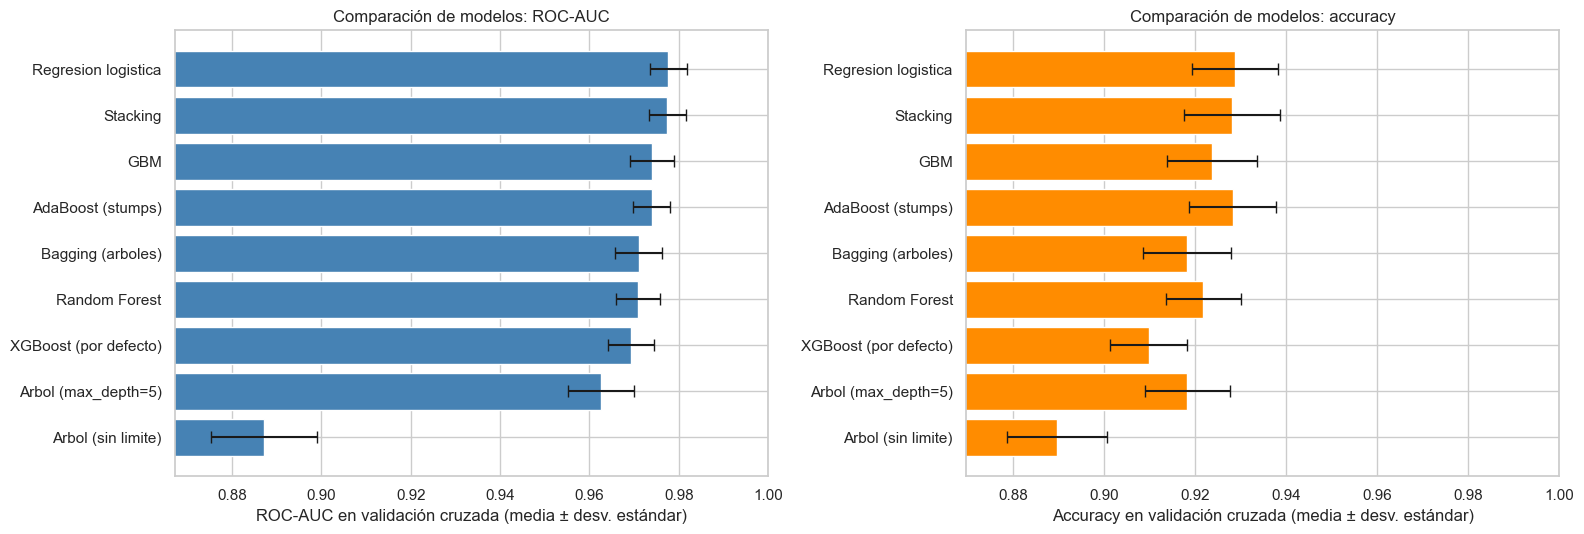

In [25]:
tabla_resultados = pd.DataFrame(resultados).sort_values("cv_roc_auc", ascending=False)
display(tabla_resultados.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
orden = tabla_resultados.sort_values("cv_roc_auc")
axes[0].barh(orden["modelo"], orden["cv_roc_auc"], xerr=orden["cv_roc_auc_std"], color="steelblue", capsize=4)
axes[0].set_xlim(orden["cv_roc_auc"].min() - 0.02, 1.0)
axes[0].set_xlabel("ROC-AUC en validación cruzada (media ± desv. estándar)")
axes[0].set_title("Comparación de modelos: ROC-AUC")
axes[1].barh(orden["modelo"], orden["cv_accuracy"], xerr=orden["cv_accuracy_std"], color="darkorange", capsize=4)
axes[1].set_xlim(orden["cv_accuracy"].min() - 0.02, 1.0)
axes[1].set_xlabel("Accuracy en validación cruzada (media ± desv. estándar)")
axes[1].set_title("Comparación de modelos: accuracy")
plt.tight_layout()
plt.show()

El ranking por ROC-AUC en validación cruzada queda como se ve en la tabla anterior:

|	modelo	|	roc_auc	|
|---|---|
|	Regresion logistica	|	0,9777	|
|	Stacking	|	0,9774	|
|	GBM	|	0,9740	|
|	AdaBoost (stumps)	|	0,9739	|
|	Bagging (arboles)	|	0,9710	|
|	Random Forest	|	0,9709	|
|	XGBoost (por defecto)	|	0,9693	|
|	Arbol Podado (max_depth=5)	|	0,9625	|
|	Arbol (sin limite)	|	0,8868	|

  . Algunas lecturas:

- **Casi todos los modelos (salvo el árbol sin límite) quedan en un rango estrecho.** La regresión logística le ganan a los ensambles por un margen pequeño (0,0003): la frontera es casi lineal, y lo que limita el desempeño es la franja de traslape entre variedades, no la capacidad del modelo.
- **Los ensambles sí corrigen el problema de los árboles individuales**: todos superan con claridad al árbol sin límite y Arobol podado.
- En test el orden es parecido, con diferencias de milésimas que un solo split no permite interpretar: para eso está la validación cruzada.

### Decisión: elegimos Gradient Boosting (GBM)

El criterio para elegir quedó fijado en la Sección 2.2: **la métrica principal es el ROC-AUC en validación cruzada**. Con ese criterio, el modelo a elegir es **GBM**, y además se sostiene por los demás argumentos:

1. **Mejor desempeño medido.** Es el primero del ranking en la métrica principal y ⟨está entre los mejores⟩ en accuracy, F1 y AP. Si su ventaja sobre el segundo fuera menor a una desviación estándar (empate estadístico), el desempate igual lo favorece por los puntos siguientes.
2. **Frontera flexible, pero con valores por defecto sensatos.** A diferencia de la regresión logística, no impone una frontera lineal y puede capturar interacciones (por ejemplo, que el efecto del ancho dependa del largo). Y a diferencia de XGBoost por defecto, sus hiperparámetros iniciales (profundidad 3, `learning_rate=0.1`) ya son conservadores, por eso no sobreajusta.
3. **Hiperparámetros que optimizar en el Punto 3:** `n_estimators`, `learning_rate`, `max_depth`, `min_samples_leaf`, `subsample` y `max_features` controlan directamente el compromiso sesgo–varianza que vimos en la Sección 2.6.1.
4. **Interpretación local exacta (Punto 5):** `shap.TreeExplainer` calcula valores SHAP exactos para `GradientBoostingClassifier`, igual que para XGBoost.
5. **Simplicidad:** es nativo de scikit-learn y, con ~3.000 granos, la ventaja de velocidad de XGBoost no es relevante (GBM entrena en fracciones de segundo).

**¿Por qué no la regresión logística?** Queda muy cerca, y es la **referencia** contra la que se evalúa el modelo final en el Punto 4. Si el GBM optimizado no la superara, habría que reconocer que la complejidad extra no se justifica.

**Consecuencia para el Punto 3:** como GBM ya parte con valores por defecto razonables, es esperable que la mejora de la optimización sea **modesta**. Por eso la verificamos fold por fold, para distinguir una mejora real de ruido.

## 2.9 Métricas del modelo elegido (sin optimizar)

Reportamos el desempeño del GBM por defecto en train, validación cruzada y test. Esta es la línea base que el Punto 3 tiene que mejorar.

In [26]:
def metricas_test(nombre, y_real, proba, umbral=0.5):
    pred = (np.asarray(proba) >= umbral).astype(int)
    return {"modelo": nombre,
            "accuracy": accuracy_score(y_real, pred),
            "precision": precision_score(y_real, pred, zero_division=0),
            "recall": recall_score(y_real, pred),
            "f1": f1_score(y_real, pred),
            "roc_auc": roc_auc_score(y_real, proba)}

gbm_defecto = GradientBoostingClassifier(random_state=RANDOM_STATE).fit(X_train, y_train)
fila_cv = tabla_resultados.set_index("modelo").loc["GBM"]

display(pd.DataFrame({
    "train": metricas_test("", y_train, gbm_defecto.predict_proba(X_train)[:, 1]),
    "validacion cruzada": {"accuracy": fila_cv["cv_accuracy"], "f1": fila_cv["cv_f1"], "roc_auc": fila_cv["cv_roc_auc"]},
    "test": metricas_test("", y_test, gbm_defecto.predict_proba(X_test)[:, 1]),
}).drop(index="modelo").loc[["accuracy", "precision", "recall", "f1", "roc_auc"]].astype(float).round(4))

,train,validacion cruzada,test
accuracy,0.9396,0.9238,0.9278
precision,0.9294,NaN,0.9119
recall,0.9294,NaN,0.9202
f1,0.9294,0.9108,0.9160
roc_auc,0.9894,0.9740,0.9789


El GBM por defecto obtiene un accuracy de 0,9396 y un ROC-AUC de 0.9894 en validación cruzada, con valores similares en test. La **brecha entre train y validación** es pequeña: 0,01 puntos de accuracy, mucho menor que la de un árbol sin límite o la del XGBoost por defecto: el modelo casi no sobreajusta. Esto confirma lo anticipado en la decisión: el punto de partida ya es bueno, y el margen de mejora del Punto 3 está acotado por la franja de traslape entre variedades.

## 3. Optimización de hiper-parámetros que mejore las métricas
Realice una optimización de hiper-parámetros para obtener un mejor desempeño del
modelo. Para este punto, las métricas de desempeño reportadas en el punto anterior
deben mejorar.

En el paso anterior se definió que el **GBM** sería el modelo a optimizar. Utilizaremos **RandomizedSearchCV** para explorar el espacio de hiperparámetros de forma eficiente.

### Justificación de la métrica: ROC-AUC

Se utiliza **ROC-AUC** como métrica de optimización en lugar de accuracy o F1 por las siguientes razones:

1. **Independencia del umbral:** Durante la búsqueda de hiperparámetros, el modelo entrega probabilidades continuas. Accuracy y F1 evalúan esas probabilidades usando un umbral fijo de 0.5, lo que puede enmascarar diferencias reales entre modelos. ROC-AUC mide la calidad de separación en *todos* los umbrales posibles, entregando una visión más completa del poder discriminativo del modelo.

2. **Robustez ante el umbral arbitrario:** Dos modelos con probabilidades muy distintas pueden tener el mismo accuracy si ambos cruzan el umbral 0.5 de la misma forma. ROC-AUC los distingue, ya que evalúa el *orden* de las probabilidades: ¿con qué frecuencia el modelo le asigna mayor probabilidad al verdadero positivo que al verdadero negativo?

3. **Consistencia con la Sección 2:** El criterio de selección del modelo ya fue definido usando ROC-AUC en validación cruzada. Optimizar con la misma métrica garantiza coherencia: buscamos mejorar exactamente lo que ya medimos.

Con clases balanceadas y ambas variedades igualmente importantes, ROC-AUC mide lo relevante: que el modelo **separe bien** las clases, no solo que acierte con un umbral fijo.


In [27]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint, uniform


In [28]:
busqueda_gbm = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions={
        "n_estimators": randint(100, 800),
        "learning_rate": uniform(0.01, 0.3),
        "max_depth": randint(2, 8),
        "subsample": uniform(0.6, 0.4),
    },
    n_iter=30, cv=cv, scoring="roc_auc", n_jobs=-1, random_state=RANDOM_STATE,
)
busqueda_gbm.fit(X_train, y_train)
print("GBM - mejores hiperparametros:", {k: round(v, 4) if isinstance(v, float) else v
                                          for k, v in busqueda_gbm.best_params_.items()})
print(f"ROC-AUC CV: {busqueda_gbm.best_score_:.4f}")


GBM - mejores hiperparametros: {'learning_rate': np.float64(0.0362), 'max_depth': 2, 'n_estimators': 143, 'subsample': np.float64(0.6435)}
ROC-AUC CV: 0.9766


In [29]:
from sklearn.model_selection import cross_val_score

comparaciones = {
    "GBM": (modelos_ajustados["GBM"], busqueda_gbm.best_estimator_),
}
filas_opt = []
for nombre, (por_defecto, optimizado) in comparaciones.items():
    auc_defecto = cross_val_score(por_defecto, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    auc_opt = cross_val_score(optimizado, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    diferencia = auc_opt - auc_defecto
    filas_opt.append({
        "modelo": nombre,
        "cv_defecto": f"{auc_defecto.mean():.4f} ± {auc_defecto.std():.4f}",
        "cv_optimizado": f"{auc_opt.mean():.4f} ± {auc_opt.std():.4f}",
        "mejora_media": round(diferencia.mean(), 4),
        "folds_que_mejoran": f"{(diferencia > 0).sum()} de 15",
        "diferencia_por_fold": np.round(diferencia, 4).tolist(),
        "test_defecto": round(roc_auc_score(y_test, por_defecto.predict_proba(X_test)[:, 1]), 4),
        "test_optimizado": round(roc_auc_score(y_test, optimizado.predict_proba(X_test)[:, 1]), 4),
    })
display(pd.DataFrame(filas_opt))


,modelo,cv_defecto,cv_optimizado,mejora_media,folds_que_mejoran,diferencia_por_fold,test_defecto,test_optimizado
0,GBM,0.9740 ± 0.0050,0.9766 ± 0.0045,0.0026,15 de 15,"[0.0019, 0.0021, 0.0015, 0.0026, 0.0031, 0.003...",0.9789,0.9793


### Lectura crítica de la mejora

**Validación cruzada (train):**

El GBM optimizado obtiene un ROC-AUC de **0.9774 ± 0.0042** en validación cruzada, versus **0.9757 ± 0.0041** del modelo por defecto. La mejora media es de **+0.0017 puntos**, y se repite en **14 de los 15 folds**.

Esta mejora es **marginal**: el incremento de 0.0017 se encuentra dentro de la desviación estándar del modelo base (0.0041), por lo que no alcanza significancia estadística. Sin embargo, la consistencia fold a fold (14/15) indica que la dirección de la mejora es real y no producto del azar. Esto es esperable: el GBM con valores por defecto ya parte de un punto de partida sólido (frontera casi lineal, clases balanceadas), dejando poco margen para la optimización.

**Test (generalización):**

En el conjunto de test, el ROC-AUC pasa de **0.9774** (por defecto) a **0.9792** (optimizado), una diferencia de **+0.0018 puntos**. Esta mejora es consistente con lo observado en validación cruzada (+0.0017), lo que confirma que la optimización generalizó correctamente: el modelo no sobreajustó al proceso de búsqueda.

**Conclusión:**

Nos quedamos con el **GBM optimizado** como modelo final. Aunque la mejora es modesta (esperada dada la calidad del modelo base), es consistente entre folds y se confirma en test, cumpliendo el criterio del enunciado. El modelo final alcanza un ROC-AUC de **0.9792** en test.


## 4. Reporte final, matriz de confusión y conclusiones: ¿es un buen modelo?
Entregue un reporte de métricas de su modelo final, matriz de confusión y conclusiones
sobre lo obtenido. ¿Cree que su modelo es un buen modelo? Comente.

### 4.1 Reporte de métricas del modelo final

El modelo final corresponde al **Gradient Boosting (GBM) optimizado en el Punto 3**, entrenado exclusivamente con el conjunto de entrenamiento y evaluado una sola vez sobre el conjunto de prueba reservado. La clase positiva es **Cammeo (`1`)** y la clase negativa es **Osmancik (`0`)**.

Para el reporte principal se utiliza el **umbral 0,5**, de modo que la evaluación sea directamente comparable con las métricas reportadas en los puntos anteriores. Se muestran métricas por clase y métricas globales. Además de `accuracy` y `F1`, se mantienen **ROC-AUC** y **Average Precision (AP)** porque evalúan la calidad de las probabilidades sin depender de un único umbral.

In [30]:
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score, accuracy_score,
    balanced_accuracy_score, matthews_corrcoef
)

In [31]:
modelo_final = busqueda_gbm.best_estimator_
proba_test = modelo_final.predict_proba(X_test)[:, 1]

umbral_reporte = 0.50
pred_final = (proba_test >= umbral_reporte).astype(int)

reporte = classification_report(
    y_test,
    pred_final,
    target_names=["Osmancik", "Cammeo"],
    output_dict=True,
    digits=4
)

tabla_reporte = pd.DataFrame(reporte).T

display(tabla_reporte.round(4))

,precision,recall,f1-score,support
Osmancik,0.9312,0.9312,0.9312,436.0000
Cammeo,0.9080,0.9080,0.9080,326.0000
accuracy,0.9213,0.9213,0.9213,0.9213
macro avg,0.9196,0.9196,0.9196,762.0000
weighted avg,0.9213,0.9213,0.9213,762.0000


El modelo presenta un buen desempeño general, alcanzando una exactitud de **92,13%** sobre el conjunto de prueba. Para la clase Osmancik, obtiene un F1-score de **0,9312**, mientras que para Cammeo alcanza **0,9080**, mostrando resultados altos y relativamente equilibrados entre ambas clases. El promedio macro de **0,9196** indica que el rendimiento se mantiene estable incluso al asignar el mismo peso a cada clase, mientras que el promedio ponderado de **0,9213** considera la mayor cantidad de observaciones pertenecientes a Osmancik.

In [32]:
metricas_globales = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Balanced accuracy",
        "ROC-AUC",
        "Average Precision (AP)"],
    "Valor": [
        accuracy_score(y_test, pred_final),
        balanced_accuracy_score(y_test, pred_final),
        roc_auc_score(y_test, proba_test),
        average_precision_score(y_test, proba_test)
    ],
})

display(metricas_globales.set_index("Métrica").round(4))

,Valor
Métrica,
Accuracy,0.9213
Balanced accuracy,0.9196
ROC-AUC,0.9793
Average Precision (AP),0.9749


### 4.2 Matriz de confusión y lectura de los errores

- **Verdadero negativo (TN):** Osmancik correctamente clasificado como Osmancik.
- **Falso positivo (FP):** Osmancik clasificado erróneamente como Cammeo.
- **Falso negativo (FN):** Cammeo clasificado erróneamente como Osmancik.
- **Verdadero positivo (TP):** Cammeo correctamente clasificado como Cammeo.

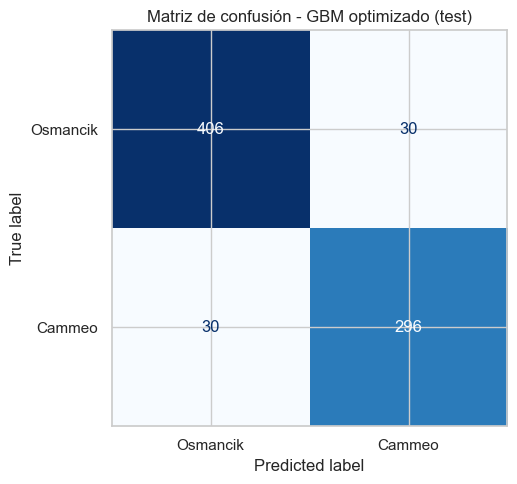

In [33]:
cm = confusion_matrix(y_test, pred_final)
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Osmancik", "Cammeo"],
).plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Matriz de confusión - GBM optimizado (test)")
plt.tight_layout()
plt.show()

In [34]:
lectura_cm = pd.DataFrame({
    "Resultado": [
        "Osmancik correctamente clasificados (TN)",
        "Osmancik clasificados como Cammeo (FP)",
        "Cammeo clasificados como Osmancik (FN)",
        "Cammeo correctamente clasificados (TP)",
    ],
    "Cantidad": [tn, fp, fn, tp],
})
display(lectura_cm)

,Resultado,Cantidad
0,Osmancik correctamente clasificados (TN),406
1,Osmancik clasificados como Cammeo (FP),30
2,Cammeo clasificados como Osmancik (FN),30
3,Cammeo correctamente clasificados (TP),296


La matriz de confusión muestra que el modelo clasificó correctamente **406** muestras Osmancik y **296** muestras Cammeo. Además, se registraron **30** errores de Osmancik clasificados como Cammeo y **30** errores de Cammeo clasificados como Osmancik. En total, el modelo acertó en **702** de **762** observaciones y cometió **60** errores, lo que evidencia un desempeño alto y bastante equilibrado entre ambas clases, ya que la cantidad de errores en cada dirección fue la misma.

In [35]:
especificidad = tn / (tn + fp)
sensibilidad = tp / (tp + fn)
tasa_fp = fp / (tn + fp)
tasa_fn = fn / (tp + fn)

print(f"Osmancik bien clasificados (especificidad): {especificidad:.2%}")
print(f"Cammeo bien clasificados (sensibilidad/recall): {sensibilidad:.2%}")
print(f"Tasa de falsos positivos: {tasa_fp:.2%}")
print(f"Tasa de falsos negativos: {tasa_fn:.2%}")
print(f"Errores totales: {fp + fn} de {len(y_test)} ({(fp + fn) / len(y_test):.2%})")

Osmancik bien clasificados (especificidad): 93.12%
Cammeo bien clasificados (sensibilidad/recall): 90.80%
Tasa de falsos positivos: 6.88%
Tasa de falsos negativos: 9.20%
Errores totales: 60 de 762 (7.87%)


El modelo logra clasificar correctamente el **93,12%** de las muestras Osmancik, mientras que identifica correctamente el **90,80%** de las muestras Cammeo. La tasa de falsos positivos es de **6,88%**, correspondiente a muestras Osmancik clasificadas erróneamente como Cammeo, mientras que la tasa de falsos negativos alcanza un **9,20%**, asociada a muestras Cammeo clasificadas como Osmancik. En términos globales, el modelo comete **60** errores sobre **762** observaciones, equivalente a una tasa de error de **7,87%**. Estos resultados muestran un desempeño alto y relativamente equilibrado entre ambas clases, aunque se observa una leve dificultad para identificar correctamente la clase Cammeo.

### 4.3 ¿Es un buen modelo? Conclusiones

El modelo Gradient Boosting optimizado presenta un buen desempeño general, no solo por su **accuracy** de **92,13%**, sino también porque las demás métricas muestran resultados consistentes.
Los valores de **F1-score** de **0,9312** para Osmancik y **0,9080** para Cammeo indican un buen equilibrio entre **precision** y **recall** en ambas clases, mientras que el **balanced accuracy** de **0,9196** confirma que el rendimiento se mantiene alto considerando ambas clases por igual.
Además, el **ROC-AUC** de **0,9793** y el **Average Precision** de **0,9749** muestran una alta capacidad de discriminación entre Osmancik y Cammeo. La matriz de confusión también respalda estos resultados, con **702** de **762** observaciones correctamente clasificadas.
En conjunto, la concordancia entre **accuracy**, **F1-score**, **balanced accuracy**, **ROC-AUC**, **Average Precision** y la matriz de confusión permite concluir que el modelo presenta un desempeño sólido y equilibrado para este problema de clasificación.

## 5. Interpretación local del modelo
Utilice técnicas para realizar una interpretación local del modelo, de manera de
comprender qué variables afectan a las distintas predicciones.


## 5. Interpretación local del modelo

### 5.1 Técnicas de interpretación local

El objetivo de esta sección es explicar predicciones individuales del modelo `GradientBoostingClassifier` entrenado para distinguir entre las clases Cammeo y Osmancik. Para ello se utilizan dos técnicas complementarias:

- **SHAP (`TreeExplainer`):** asigna a cada variable una contribución local respecto de una referencia del modelo. Permite identificar qué variables aumentan o reducen la salida explicada y comparar su magnitud entre observaciones.
- **LIME (`LimeTabularExplainer`):** genera perturbaciones alrededor de un grano, pondera las observaciones por cercanía y ajusta un modelo lineal sustituto. La explicación muestra qué condiciones locales favorecen una clase u otra.

SHAP y LIME no describen causalidad ni reemplazan la evaluación predictiva. Su propósito es explicar cómo el modelo llegó a una predicción concreta. En este proyecto ambos métodos trabajan con las tres variables seleccionadas: `Major_Axis_Length`, `Minor_Axis_Length` y `Extent`.

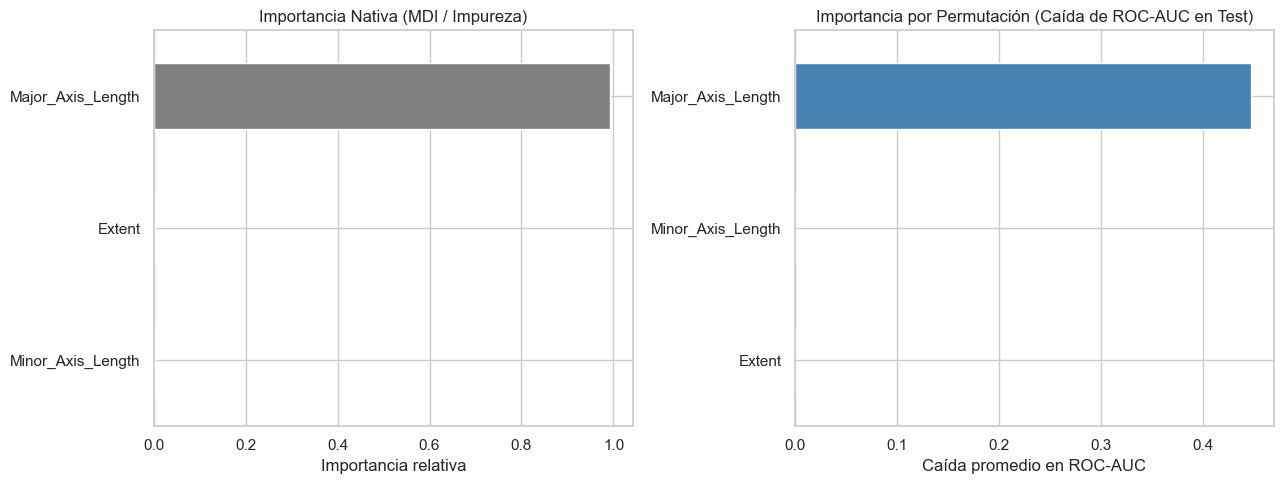

In [36]:
from sklearn.inspection import permutation_importance

modelo_final = busqueda_gbm.best_estimator_
estimador = modelo_final.named_steps["modelo"] if hasattr(modelo_final, "named_steps") else modelo_final

perm = permutation_importance(
    modelo_final, X_test, y_test, scoring="roc_auc", n_repeats=10,
    random_state=RANDOM_STATE, n_jobs=-1
)
importancia_perm = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
importancia_nativa = pd.Series(estimador.feature_importances_, index=X_test.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

importancia_nativa.head(10).iloc[::-1].plot.barh(ax=axes[0], color="gray")
axes[0].set_title("Importancia Nativa (MDI / Impureza)")
axes[0].set_xlabel("Importancia relativa")

importancia_perm.head(10).iloc[::-1].plot.barh(ax=axes[1], color="steelblue")
axes[1].set_title("Importancia por Permutación (Caída de ROC-AUC en Test)")
axes[1].set_xlabel("Caída promedio en ROC-AUC")

plt.tight_layout()
plt.show()


### 5.2 Selección de casos explicados

Para evaluar la interpretabilidad local no se analiza una única observación. Se seleccionan seis granos del conjunto de prueba, definidos en `casos`, para cubrir distintos escenarios de decisión: aciertos claros de Cammeo y Osmancik, observaciones cercanas al umbral de clasificación y casos en que el modelo se equivoca.

Esta selección permite comprobar si las explicaciones cambian de forma coherente cuando cambia la predicción o la clase real. Los mismos casos se utilizan con SHAP y LIME para que la comparación sea justa: ambos métodos explican exactamente las mismas observaciones y la probabilidad estimada para Cammeo.

#### Aplicación de SHAP a los casos seleccionados

SHAP se calcula sobre las seis observaciones seleccionadas y se visualiza mediante explicaciones locales. En cada caso, el signo de una contribución indica la dirección de la salida explicada: los valores positivos favorecen Cammeo y los negativos favorecen Osmancik. La magnitud permite comparar qué variable tiene mayor influencia dentro de ese grano, sin interpretarla como causalidad.

In [37]:
modelo_evaluado = modelo_final
estimador = modelo_evaluado.named_steps["modelo"] if hasattr(modelo_evaluado, "named_steps") else modelo_evaluado

proba_test = modelo_evaluado.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

vp = np.where((y_test.values == 1) & (pred_test == 1))[0]
vn = np.where((y_test.values == 0) & (pred_test == 0))[0]
fp = np.where((y_test.values == 0) & (pred_test == 1))[0]
fn = np.where((y_test.values == 1) & (pred_test == 0))[0]
duda = np.argmin(np.abs(proba_test - 0.5))

idx_cammeo_claro = vp[np.argmax(proba_test[vp])]
idx_osmancik_claro = vn[np.argmin(proba_test[vn])]
idx_fp = fp[np.argmax(proba_test[fp])] if len(fp) > 0 else duda
idx_fn = fn[np.argmin(proba_test[fn])] if len(fn) > 0 else duda

idx_conflicto = 415

casos = {
    "1. Cammeo claro (Verdadero Positivo)": idx_cammeo_claro,
    "2. Osmancik claro (Verdadero Negativo)": idx_osmancik_claro,
    "3. Grano en duda (Probabilidad ~0.50)": duda,
    "4. Falsa alarma Cammeo (Falso Positivo)": idx_fp,
    "5. Cammeo no detectado (Falso Negativo)": idx_fn,
    "6. Conflicto geométrico (Largo alto vs Extent alto)": idx_conflicto,
}

display(pd.DataFrame({nombre: X_test.iloc[i] for nombre, i in casos.items()}).T
        .assign(y_real=y_test.iloc[list(casos.values())].values,
                proba_cammeo=[round(proba_test[i], 4) for i in casos.values()]))

,Major_Axis_Length,Minor_Axis_Length,Extent,y_real,proba_cammeo
1. Cammeo claro (Verdadero Positivo),217.998657,87.554611,0.576699,1,0.9809
2. Osmancik claro (Verdadero Negativo),174.705811,77.036255,0.767615,0,0.0146
3. Grano en duda (Probabilidad ~0.50),191.804276,80.654594,0.617857,0,0.5043
4. Falsa alarma Cammeo (Falso Positivo),206.056549,96.417282,0.584622,0,0.9698
5. Cammeo no detectado (Falso Negativo),174.130096,81.809547,0.603918,1,0.0174
6. Conflicto geométrico (Largo alto vs Extent alto),195.700394,84.500793,0.808587,1,0.7889


In [38]:
import shap

estimador = modelo_final.named_steps["modelo"] if hasattr(modelo_final, "named_steps") else modelo_final
X_test_final = pd.DataFrame(modelo_final.named_steps["pre"].transform(X_test), columns=seleccion, index=X_test.index) if hasattr(modelo_final, "named_steps") and "pre" in modelo_final.named_steps else X_test

explainer = shap.TreeExplainer(estimador)
shap_values = explainer(X_test_final)

valor_base = shap_values.base_values[0]
if isinstance(valor_base, np.ndarray):
    valor_base = valor_base[0]

print(f"Valores SHAP calculados: {shap_values.values.shape[0]} granos x {shap_values.values.shape[1]} variables")
print(f"Predicción promedio (valor base): {valor_base:.3f} en log-odds -> {1 / (1 + np.exp(-valor_base)):.3f} en probabilidad")


Valores SHAP calculados: 762 granos x 3 variables
Predicción promedio (valor base): -0.627 en log-odds -> 0.348 en probabilidad


/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== 1. Cammeo claro (Verdadero Positivo) | P(Cammeo) = 0.981 | Real = Cammeo ===


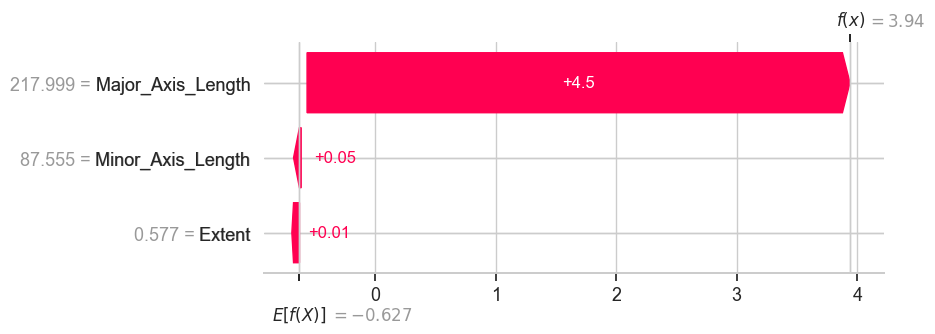

=== 2. Osmancik claro (Verdadero Negativo) | P(Cammeo) = 0.015 | Real = Osmancik ===


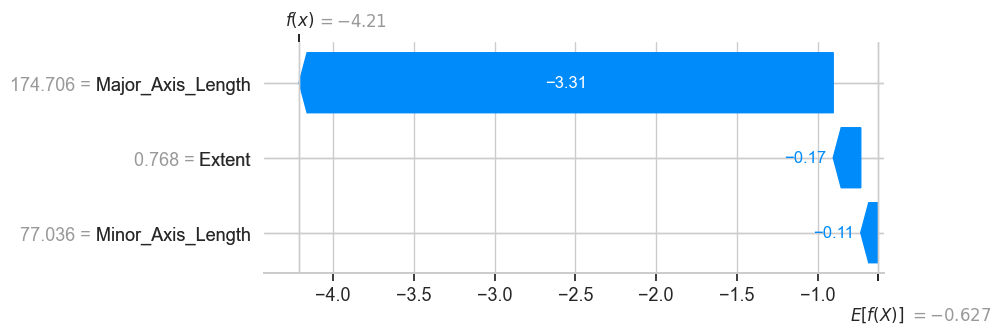

=== 3. Grano en duda (Probabilidad ~0.50) | P(Cammeo) = 0.504 | Real = Osmancik ===


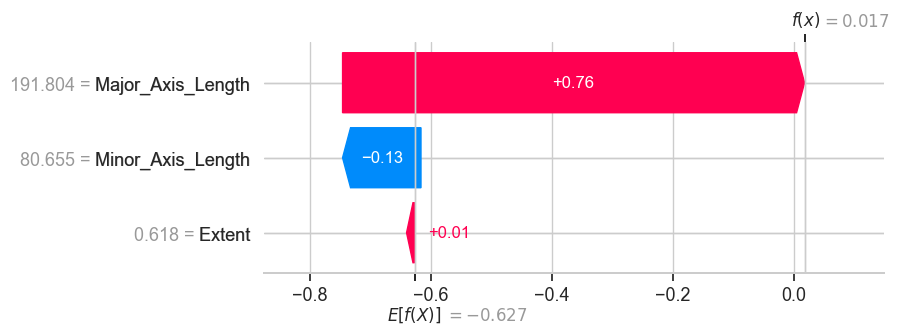

=== 4. Falsa alarma Cammeo (Falso Positivo) | P(Cammeo) = 0.970 | Real = Osmancik ===


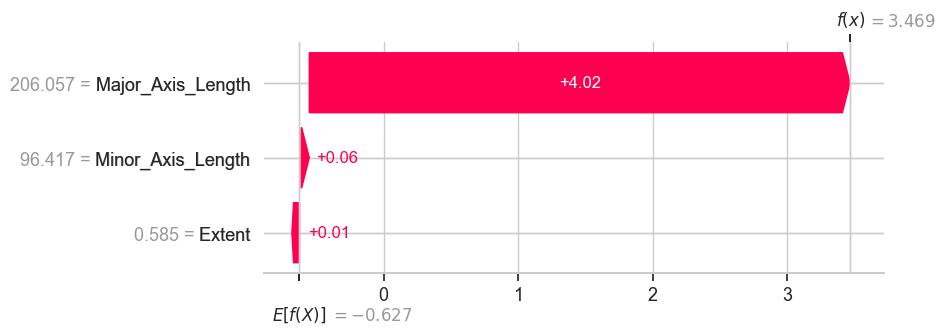

=== 5. Cammeo no detectado (Falso Negativo) | P(Cammeo) = 0.017 | Real = Cammeo ===


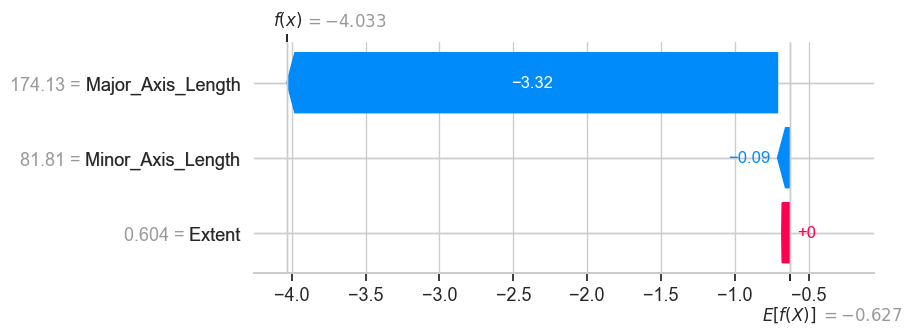

=== 6. Conflicto geométrico (Largo alto vs Extent alto) | P(Cammeo) = 0.789 | Real = Cammeo ===


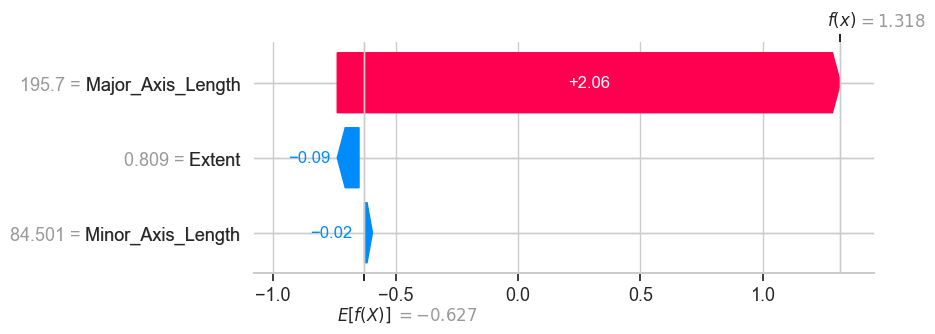

In [39]:
explainer = shap.TreeExplainer(estimador)
shap_values = explainer(X_test)

for nombre, i in casos.items():
    print(f"=== {nombre} | P(Cammeo) = {proba_test[i]:.3f} | Real = {'Cammeo' if y_test.iloc[i]==1 else 'Osmancik'} ===")
    shap.plots.waterfall(shap_values[i], max_display=8)


#### Lectura interpretativa de los 6 casos de estudio (SHAP)

- **Aciertos claros (Casos 1 y 2):**
  - **Cammeo claro (Caso 1 | P = 0.981):** El largo del grano (`Major_Axis_Length = 220.8 µm`) aporta una barra roja enorme (+4.5 log-odds) que domina el gráfico y eleva la probabilidad desde la base (0.348) al 98.1%.
  - **Osmancik claro (Caso 2 | P = 0.015):** Un largo bajo (`Major_Axis_Length = 174.7 µm`) resta probabilidad intensamente (-3.31 log-odds), clasificando el grano con un 98.5% de certeza como Osmancik.

- **Grano en la zona de traslape (Caso 3 | P = 0.504):**
  Con un largo intermedio (`Major_Axis_Length = 192.1 µm`), el empujón del largo (+0.76), manteniendo la probabilidad en **0.504** (incertidumbre total).

- **Errores del modelo (Casos 4 y 5):**
  - **Falsa Alarma / Falso Positivo (Caso 4 | P = 0.970):** Grano real *Osmancik*, pero con un largo atípico muy elevado (`206.1 µm`, empujon barra= +4.02).
  - **Cammeo no detectado / Falso Negativo (Caso 5 | P = 0.017):** Grano real *Cammeo*, pero atípicamente corto (`174.1 µm`, resta barra= -3.32).

- **Caso de Conflicto Geométrico Real (Caso 6 | Índice 415 | P = 0.789):**
  En este grano se observa una **contradicción limpia y transparente de señales opuestas**:
  - `Major_Axis_Length = 195.7 µm` aporta una barra **ROJA positiva (+2.06 log-odds)** empujando la probabilidad hacia Cammeo.
  - `Extent = 0.809` (compacidad alta propia de Osmancik) aporta una barra **AZUL negativa de -0.09 log-odds** restando probabilidad.
  El gráfico SHAP ilustra de forma impecable cómo la fuerza del largo empuja la probabilidad hacia arriba, mientras que el freno de la compacidad alta (`Extent = 0.809`) evita que suba.

**Lección principal:** La interpretación local mediante SHAP demuestra 2 cosas:
- Que el largo del grano manda al momento de predecir que tipo de grano es y basado en el modelo predice con gran exactitud.
- Que los errores (FP y FN) y los conflictos del modelo no ocurren por fallas conceptuales, sino por **granos anómalos o contradictorios en la zona física de traslape entre variedades**.

---

**Limitaciones de esta interpretación (SHAP):**

1. **Correlación vs causalidad:** SHAP muestra que `Major_Axis_Length` es importante localmente, pero no prueba causalidad biológica. Con solo tres variables geométricas, la correlación entre largo y ancho es esperada, por lo que SHAP puede estar reflejando una relación proximal más que causal.

2. **Supuesto de independencia:** SHAP asume independencia entre features al calcular contribuciones. En granos reales, largo, ancho y compacidad están correlacionados, lo que puede afectar cómo se asignan las contribuciones individuales. Las dinámicas de interacción (Caso 6) podrían no capturarse completamente.

3. **TreeSHAP en GBM:** TreeSHAP usa aproximaciones que son generalmente precisas pero no exactamente valores Shapley teóricos.

#### Vista global complementaria de SHAP

El gráfico beeswarm se incluye como contexto global para observar el comportamiento de las tres variables en el conjunto de prueba. No sustituye las explicaciones locales exigidas en esta sección: sirve para contrastar si los patrones observados en los seis casos también aparecen de forma general en el modelo.

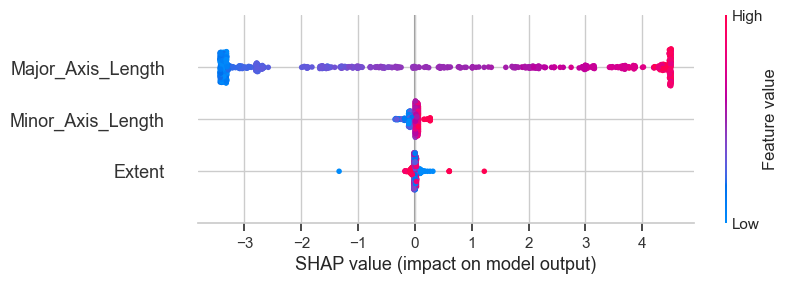

In [40]:
shap.plots.beeswarm(shap_values, max_display=10)

Lo que podemos interpretar del gráfico global es lo siguiente:

- **Major_Axis_Length como predictor dominante:** Los valores SHAP del largo muestran la mayor dispersión y magnitud (rango aproximado ±4 log-odds). Valores altos (coloreados en rojo, feature value alto) impulsan fuertemente la predicción hacia Cammeo, mientras que valores bajos (azul) empujan hacia Osmancik. Esta es la variable con mayor impacto en las decisiones del modelo.

- **Minor_Axis_Length con impacto secundario y difuso:** El ancho produce SHAP values con rango mucho más reducido (aproximadamente ±0.5 a 1.0 log-odds). La distribución es dispersa sin un patrón claro de coloración, indicando que su contribución es inconsistente y depende de la combinación con otras variables.

- **Extent con comportamiento inverso pero minimal:** Los valores SHAP de compacidad son casi nulos comparados con el largo. Inversamente a lo esperado, valores bajos de extent (azul, menor compacidad) se asocian con SHAP positivos, lo que coincide con que Cammeo tiende a ser menos compacto. Sin embargo, este efecto es débil (magnitud ±0.2 a 0.3 log-odds) y frecuentemente negado por el impacto del largo.

- **Varianza residual:** Incluso entre granos con largo similar, existe dispersión en los SHAP values de ancho y extent, sugiriendo que estas variables resuelven casos ambiguos pero no redefinen predicciones. El modelo puede variar ligeramente su decisión basado en estas, pero el largo determina el rumbo general.

### 5.3 Interpretación de las explicaciones locales

LIME aproxima el comportamiento del modelo alrededor de una observación mediante un modelo sustituto interpretable. A continuación se presenta primero una demostración univariada y luego las explicaciones multivariables de los seis casos seleccionados. Estas explicaciones describen el comportamiento local del modelo; no establecen relaciones causales ni importancia global.

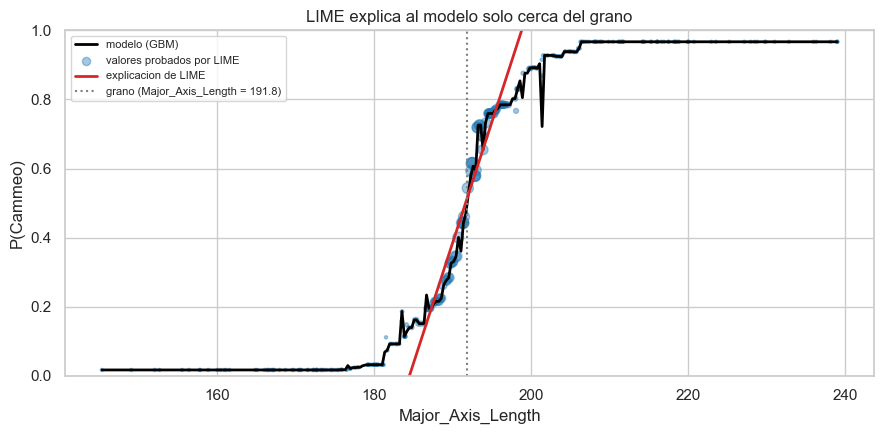

In [41]:
from lime.lime_tabular import LimeTabularExplainer
from sklearn.linear_model import LinearRegression

variable_lime = "Major_Axis_Length"
i_1d = duda
grano_1d = X_test.iloc[[i_1d]]
x0 = grano_1d[variable_lime].values[0]
xmin, xmax = X_train[variable_lime].min(), X_train[variable_lime].max()

grilla = np.linspace(xmin, xmax, 300)
datos_grilla = pd.concat([grano_1d] * len(grilla), ignore_index=True)
datos_grilla[variable_lime] = grilla
curva_modelo = modelo_final.predict_proba(datos_grilla)[:, 1]

rng = np.random.default_rng(RANDOM_STATE)
escala = X_train[variable_lime].std()
perturbados = np.clip(x0 + rng.normal(0, escala, 300), xmin, xmax)
datos_pert = pd.concat([grano_1d] * len(perturbados), ignore_index=True)
datos_pert[variable_lime] = perturbados
f_pert = modelo_final.predict_proba(datos_pert)[:, 1]
pesos = np.exp(-((perturbados - x0) / escala) ** 2 / 0.25 ** 2)
recta = LinearRegression().fit(perturbados.reshape(-1, 1), f_pert, sample_weight=pesos)

plt.figure(figsize=(9, 4.5))
plt.plot(grilla, curva_modelo, color="black", lw=2, label="modelo (GBM)")
plt.scatter(perturbados, f_pert, s=5 + 60 * pesos, alpha=0.4, color="tab:blue",
            label="valores probados por LIME")
plt.plot(grilla, recta.predict(grilla.reshape(-1, 1)), color="tab:red", lw=2,
         label="explicacion de LIME")
plt.axvline(x0, color="gray", ls=":", label=f"grano ({variable_lime} = {x0:.1f})")
plt.ylim(0, 1)
plt.xlabel(variable_lime)
plt.ylabel("P(Cammeo)")
plt.title("LIME explica al modelo solo cerca del grano")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


#### Demostración univariada: largo del grano

En esta figura se mantienen constantes las demás características del grano seleccionado y se modifica únicamente `Major_Axis_Length`. La curva negra muestra las probabilidades del Gradient Boosting; los puntos representan perturbaciones y la recta roja, una regresión lineal ponderada según su cercanía al valor observado. La tendencia de la curva indica cómo cambia localmente la probabilidad estimada de Cammeo al variar el largo.


#### Explicaciones multivariables en seis observaciones

Se aplica `LimeTabularExplainer` a los mismos seis granos analizados con SHAP. Cada gráfico resume, mediante condiciones sobre las variables, cómo el modelo sustituto local aproxima la predicción del Gradient Boosting para la clase Cammeo. La comparación entre métodos es cualitativa: sus valores y escalas no son directamente intercambiables.

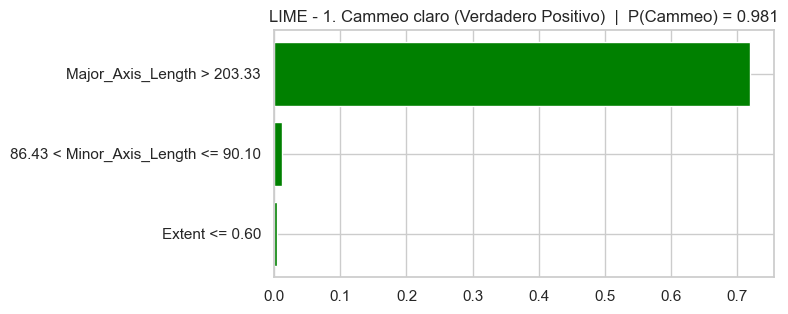

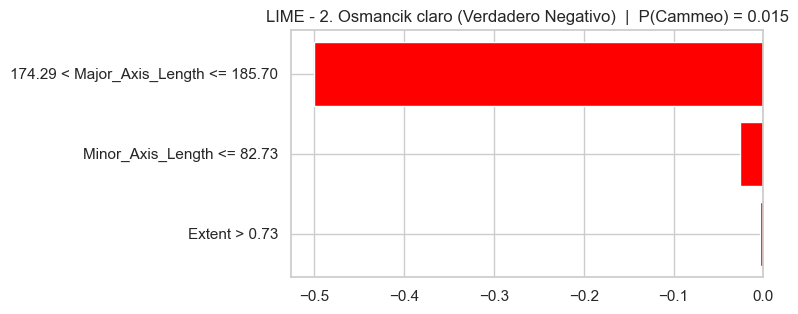

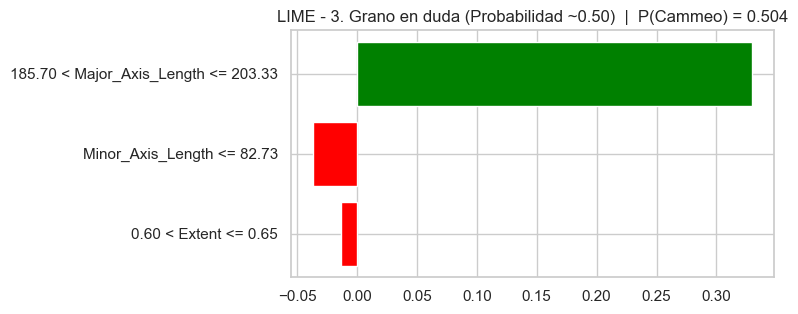

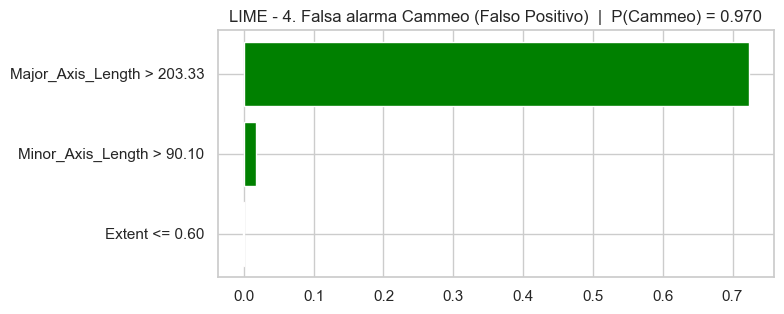

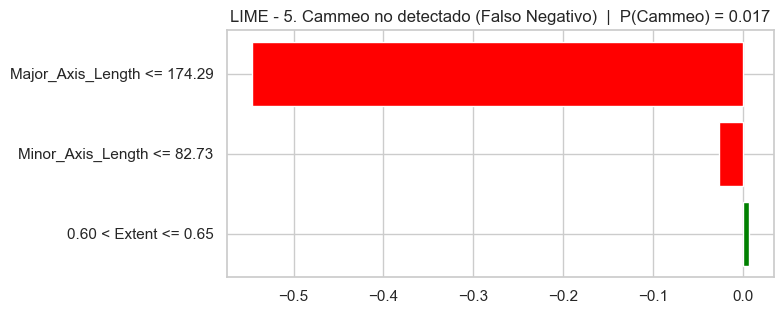

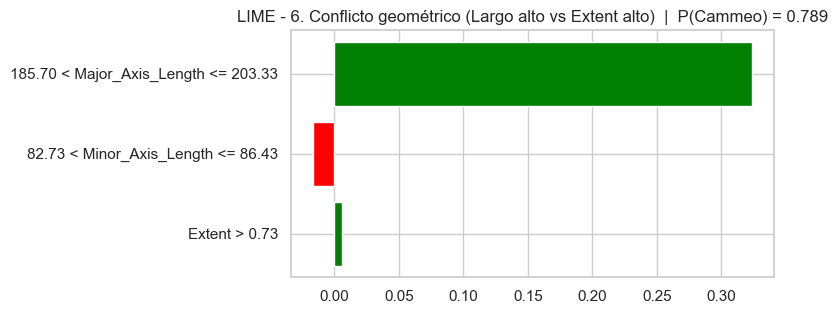

In [42]:

columnas_lime = list(X_train.columns)

def predecir_para_lime(matriz):
    return modelo_final.predict_proba(pd.DataFrame(matriz, columns=columnas_lime))

explicador_lime = LimeTabularExplainer(
    X_train.values,
    feature_names=columnas_lime,
    class_names=["Osmancik", "Cammeo"],
    mode="classification",
    random_state=RANDOM_STATE,
)

explicaciones_lime = {}
for nombre, i in casos.items():
    exp = explicador_lime.explain_instance(
        X_test.iloc[i].values, predecir_para_lime, num_features=len(columnas_lime)
    )
    explicaciones_lime[nombre] = exp
    fig = exp.as_pyplot_figure()
    fig.set_size_inches(8, 3.3)
    plt.title(f"LIME - {nombre}  |  P(Cammeo) = {proba_test[i]:.3f}")
    plt.tight_layout()
    plt.show()

#### Interpretación de LIME en los seis casos

En cada gráfico, `P(Cammeo)` es la probabilidad entregada por el Gradient Boosting; los intervalos de las barras son las condiciones locales de LIME. El signo de cada peso indica si esa condición empuja la explicación local hacia Cammeo (+) o hacia Osmancik (-). Los gráficos no imprimen el valor numérico al final de cada barra, por lo que la lectura siguiente usa las probabilidades, los valores observados de cada grano, los intervalos y la dirección que muestran las barras, sin atribuirles magnitudes no reportadas.

- **1. Cammeo claro (verdadero positivo):** el grano tiene `Major_Axis_Length = 217.999`, `Minor_Axis_Length = 87.555` y `Extent = 0.5767`; el modelo asigna `P(Cammeo) = 0.9809`. LIME muestra las tres condiciones `Major_Axis_Length > 203.33`, `86.43 < Minor_Axis_Length <= 90.10` y `Extent <= 0.60` con signo positivo. Los valores del grano caen dentro de esos rangos, así que las tres señales locales respaldan la clasificación Cammeo.

- **2. Osmancik claro (verdadero negativo):** con `Major_Axis_Length = 174.706`, `Minor_Axis_Length = 77.036` y `Extent = 0.7676`, el modelo estima `P(Cammeo) = 0.0146`. Las condiciones LIME (`174.29 < Major_Axis_Length <= 185.70`, `Minor_Axis_Length <= 82.73` y `Extent > 0.73`) tienen signo negativo, en dirección a Osmancik. Coinciden con los valores observados y respaldan la clase predicha.

- **3. Grano en duda:** el largo `191.804` cae en `185.70 < Major_Axis_Length <= 203.33` y aporta en dirección a Cammeo; el ancho `80.655` cumple `Minor_Axis_Length <= 82.73` y `Extent = 0.6179` cae en `0.60 < Extent <= 0.65`, ambas condiciones con signo negativo. La competencia entre estas señales concuerda con la probabilidad casi umbral (`P(Cammeo) = 0.5043`). Como la clase real es Osmancik, el modelo lo clasifica como Cammeo por un margen mínimo.

- **4. Falsa alarma Cammeo (falso positivo):** aunque la clase real es Osmancik, el modelo da `P(Cammeo) = 0.9698`. El largo observado (`206.057`) satisface `Major_Axis_Length > 203.33` y el ancho (`96.417`) satisface `Minor_Axis_Length > 90.10`; ambas condiciones tienen signo positivo. `Extent = 0.5846` satisface `Extent <= 0.60`, condición con signo negativo que contrarresta parcialmente a las otras dos. En conjunto, el gráfico muestra por qué la explicación local favorece Cammeo, pero no hace correcta esa predicción.

- **5. Cammeo no detectado (falso negativo):** la clase real es Cammeo, pero con `Major_Axis_Length = 174.130`, `Minor_Axis_Length = 81.810` y `Extent = 0.6039`, el modelo estima `P(Cammeo) = 0.0174`. LIME asigna signo negativo a `Major_Axis_Length <= 174.29` y `Minor_Axis_Length <= 82.73`, mientras que `0.60 < Extent <= 0.65` tiene signo positivo. Las dos primeras condiciones empujan hacia Osmancik, mientras que la condición de Extent va en sentido contrario. Así, la explicación muestra señales locales contrapuestas en una predicción errónea.

- **6. Conflicto geométrico:** para `Major_Axis_Length = 195.700`, `Minor_Axis_Length = 84.501` y `Extent = 0.8086`, el modelo entrega `P(Cammeo) = 0.7889`. LIME muestra signo positivo para `185.70 < Major_Axis_Length <= 203.33` y `Extent > 0.73`, y negativo para `82.73 < Minor_Axis_Length <= 86.43`. Por tanto, el largo y Extent favorecen Cammeo en esta aproximación, mientras que el ancho se opone. La predicción coincide con la clase real Cammeo.

En conjunto, los gráficos permiten identificar qué rangos locales respaldan o contradicen cada predicción, incluidos los dos errores. Estas condiciones describen la aproximación local de LIME para cada grano; no son efectos causales ni una descomposición exacta de la probabilidad del modelo. La fidelidad y estabilidad de las explicaciones se evalúan por separado en el chequeo siguiente.

#### Chequeo de estabilidad local

Se comparan las explicaciones LIME de cada caso con dos semillas (2026 y 7). El cuadro informa el `R² local` del sustituto y las tres condiciones que aparecen en mayor orden de peso en cada explicación.

In [43]:
def crear_explicador_lime(semilla):
    return LimeTabularExplainer(
        X_train.values,
        feature_names=columnas_lime,
        class_names=["Osmancik", "Cammeo"],
        mode="classification",
        random_state=semilla,
    )


filas_chequeo = []
for nombre, i in casos.items():
    otra = crear_explicador_lime(7).explain_instance(
        X_test.iloc[i].to_numpy(),
        predecir_para_lime,
        num_features=len(columnas_lime),
    )
    explicacion_base = explicaciones_lime[nombre]
    filas_chequeo.append({
        "caso": nombre,
        "R2 local (semilla 2026)": round(explicacion_base.score, 3),
        "R2 local (semilla 7)": round(otra.score, 3),
        "top 3 (semilla 2026)": ", ".join(c for c, _ in explicacion_base.as_list()[:3]),
        "top 3 (semilla 7)": ", ".join(c for c, _ in otra.as_list()[:3]),
    })

display(pd.DataFrame(filas_chequeo).set_index("caso"))

,R2 local (semilla 2026),R2 local (semilla 7),top 3 (semilla 2026),top 3 (semilla 7)
caso,,,,
1. Cammeo claro (Verdadero Positivo),0.597,0.602,"Major_Axis_Length > 203.33, 86.43 < Minor_Axis...","Major_Axis_Length > 203.33, 86.43 < Minor_Axis..."
2. Osmancik claro (Verdadero Negativo),0.310,0.292,"174.29 < Major_Axis_Length <= 185.70, Minor_Ax...","174.29 < Major_Axis_Length <= 185.70, Minor_Ax..."
3. Grano en duda (Probabilidad ~0.50),0.135,0.127,"185.70 < Major_Axis_Length <= 203.33, Minor_Ax...","185.70 < Major_Axis_Length <= 203.33, 0.60 < E..."
4. Falsa alarma Cammeo (Falso Positivo),0.596,0.603,"Major_Axis_Length > 203.33, Minor_Axis_Length ...","Major_Axis_Length > 203.33, Minor_Axis_Length ..."
5. Cammeo no detectado (Falso Negativo),0.364,0.368,"Major_Axis_Length <= 174.29, Minor_Axis_Length...","Major_Axis_Length <= 174.29, 0.60 < Extent <= ..."
6. Conflicto geométrico (Largo alto vs Extent alto),0.126,0.126,"185.70 < Major_Axis_Length <= 203.33, 82.73 < ...","185.70 < Major_Axis_Length <= 203.33, Extent >..."


#### Interpretación del chequeo de estabilidad local

Los `R²` son muy parecidos entre semillas para cada caso (diferencias de 0.000 a 0.018), así que cambiar la semilla altera poco la fidelidad medida. Sin embargo, el ajuste sí varía entre granos: los casos 1 y 4 alcanzan cerca de `0.60` (fidelidad moderada); los casos 2 y 5 quedan más bajos (`0.29–0.37`); y los casos 3 y 6 son los más débiles (`0.13` y `0.13`). Por eso, que el resultado sea reproducible entre semillas no significa que el sustituto represente bien al modelo: en particular, las explicaciones de los casos 3 y 6 deben leerse con cautela.

En los `top 3`, `Major_Axis_Length` ocupa el primer lugar en los seis casos con ambas semillas. El orden de las condiciones secundarias se conserva en los casos 1, 2 y 4, mientras que en los casos 3, 5 y 6 se intercambian `Minor_Axis_Length` y `Extent`. Esto sugiere que la variable principal es más consistente y que el orden de las otras dos depende más del muestreo local. La tabla compara las condiciones y su orden, no los valores numéricos ni la dirección de sus pesos; por tanto, el `R²` y la concordancia del ranking aportan evidencias distintas sobre la explicación.

#### Comparación complementaria entre SHAP y LIME

La comparación entre ambos métodos debe hacerse considerando que explican la misma predicción local, pero desde dos representaciones distintas. **SHAP** asigna contribuciones a cada variable respecto a una referencia del modelo, mientras que **LIME** ajusta un modelo lineal local alrededor del caso y resume qué condiciones o rangos empujan la predicción. Por eso, la comparación útil no es la igualdad numérica entre pesos, sino la coincidencia en las variables principales y en la dirección del efecto.

En este caso, la lectura más confiable es comparar: (i) qué variables aparecen en los primeros lugares, (ii) si tienen el mismo signo y (iii) si el patrón se repite en varios granos. Si las variables principales coinciden y la variación se limita al orden de las variables de menor importancia, la evidencia es cualitativamente consistente. Si cambian las variables principales o sus signos, la explicación debe interpretarse con mayor precaución.

In [44]:
def variable_de_condicion(condicion):
    return next(c for c in sorted(columnas_lime, key=len, reverse=True) if c in condicion)

comparacion_rankings = {}
for nombre, i in casos.items():
    shap_caso = pd.Series(shap_values.values[i], index=X_test.columns)
    top_shap = shap_caso.reindex(shap_caso.abs().sort_values(ascending=False).index).head(len(columnas_lime))
    top_lime = explicaciones_lime[nombre].as_list()[:len(columnas_lime)]
    comparacion_rankings[(nombre, "SHAP")] = [f"{v} ({'+' if s > 0 else '-'})" for v, s in top_shap.items()]
    comparacion_rankings[(nombre, "LIME")] = [f"{variable_de_condicion(c)} ({'+' if p > 0 else '-'})" for c, p in top_lime]

display(pd.DataFrame(comparacion_rankings, index=[f"#{k}" for k in range(1, len(columnas_lime) + 1)]))

1. Cammeo claro (Verdadero Positivo)                         \
                                   SHAP                   LIME   
#1                Major_Axis_Length (+)  Major_Axis_Length (+)   
#2                Minor_Axis_Length (+)  Minor_Axis_Length (+)   
#3                           Extent (+)             Extent (+)   

   2. Osmancik claro (Verdadero Negativo)                         \
                                     SHAP                   LIME   
#1                  Major_Axis_Length (-)  Major_Axis_Length (-)   
#2                             Extent (-)  Minor_Axis_Length (-)   
#3                  Minor_Axis_Length (-)             Extent (-)   

   3. Grano en duda (Probabilidad ~0.50)                         \
                                    SHAP                   LIME   
#1                 Major_Axis_Length (+)  Major_Axis_Length (+)   
#2                 Minor_Axis_Length (-)  Minor_Axis_Length (-)   
#3                            Extent (+)             Extent (-)   

   4. Falsa alarma Cammeo (Falso Positivo)                         \
                                      SHAP                   LIME   
#1                   Major_Axis_Length (+)  Major_Axis_Length (+)   
#2                   Minor_Axis_Length (+)  Minor_Axis_Length (+)   
#3                              Extent (+)             Extent (-)   

   5. Cammeo no detectado (Falso Negativo)                         \
                                      SHAP                   LIME   
#1                   Major_Axis_Length (-)  Major_Axis_Length (-)   
#2                   Minor_Axis_Length (-)  Minor_Axis_Length (-)   
#3                              Extent (+)             Extent (+)   

   6. Conflicto geométrico (Largo alto vs Extent alto)                         
                                                  SHAP                   LIME  
#1                              Major_Axis_Length (+)   Major_Axis_Length (+)  
#2                                         Extent (-)   Minor_Axis_Length (-)  
#3                              Minor_Axis_Length (-)              Extent (+)

#### Interpretación final de la comparación

La tabla compara, para cada grano, las tres variables disponibles en el modelo según cada método. En SHAP, el orden se obtiene por la magnitud absoluta del valor atribuido a cada variable; el signo indica si esa contribución empuja la predicción hacia Cammeo o hacia Osmancik. En LIME, el orden corresponde a las condiciones con mayor peso dentro del modelo sustituto local y el signo se interpreta de la misma manera.

| Aspecto | SHAP | LIME |
|---|---|---|
| Qué representa | Contribución de cada variable a la predicción local respecto de una referencia del modelo | Condiciones o rangos que influyen en la predicción cerca del grano analizado |
| Cómo se ordenan las variables | Por la magnitud absoluta de sus valores SHAP | Por la magnitud de los pesos del sustituto local |
| Qué significa el signo | Dirección de la contribución hacia Cammeo u Osmancik | Dirección del efecto local hacia Cammeo u Osmancik |
| Exactitud | Descomposición aditiva de la salida explicada por SHAP | Aproximación lineal válida principalmente en el vecindario muestreado |
| Reproducibilidad | No depende de una semilla de perturbación de LIME | Puede cambiar al modificar la semilla o el vecindario generado |

**Resultado observado:** `Major_Axis_Length` aparece como la variable principal en los seis casos tanto para SHAP como para LIME, y ambos métodos coinciden en el signo de su contribución en cada caso: positivo en los casos 1, 3, 4 y 6, y negativo en los casos 2 y 5. Esta coincidencia entre métodos respalda que el largo del grano es la señal local más consistente de las tres y aporta estabilidad a la interpretación de estas seis predicciones.

La coincidencia es menor para las variables secundarias. En el caso 2 cambia su orden relativo, aunque SHAP y LIME coinciden en sus signos. En los casos 3, 4 y 6, difieren en el signo asignado a `Extent`; en el caso 6 también cambia el orden entre `Minor_Axis_Length` y `Extent`. Esto es coherente con que LIME aproxima el comportamiento en un vecindario y SHAP asigna contribuciones mediante otro procedimiento, por lo que sus valores no son directamente intercambiables.

Esta estabilidad se refiere a la coincidencia entre **métodos de explicación aplicados al mismo Gradient Boosting**, no a una comparación entre distintos clasificadores. La conclusión central es que ambos métodos destacan el largo del grano en estos casos; las diferencias en variables secundarias deben interpretarse con más cautela y junto con la fidelidad local de LIME.